# Revisions- Figure 2, 5-7 + Supp Figure 1,2 Analysis and Figure Code

*Description*
Code for analysis and figures in Fig 2, 5-7 and Supp. Fig. 1.
v2- streamlines how figures are made

*Run Order*
- Setup Environment and Imports
- Load & Process Data
- Generate figure outputs for
    - Figure 2: E, F, G, H
    - Figure 5: A
    - Figure 6: A
    - Figure 7: A, E
    - Supp. Fig. 1: B, C, D, E, F, G, H, I, J
    - Supp. Fig. 2: A, B


## Setup


In [1]:
%load_ext autoreload
%autoreload 2


In [2]:
%pip install -r ../requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [3]:


from pathlib import Path
import os
import notebook_setup
info = notebook_setup.setup()
# set up plotting code
import matplotlib as matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline 
# Apply mplstyle via absolute path from setup info
style_path = Path(info["function_py_storage"]) / "paper_plot.mplstyle"
print(f"Loading style guide at {style_path}")
if style_path.is_file():
    plt.style.use(str(style_path))
else:
    print(f"[warn] Style not found at: {style_path}")
    
#  Environment & Imports Setup
import numpy as np
import warnings
import pandas as pd

# Fix for seaborn 0.12.1 + pandas 2.0 compatibility
try:
    pd.get_option('mode.use_inf_as_null')
except (pd.errors.OptionError, KeyError):
    pd._config.config._global_config['mode']['use_inf_as_null'] = False
    pd._config.config._registered_options['mode.use_inf_as_null'] = pd._config.config.RegisteredOption(
        key='mode.use_inf_as_null',
        defval=False,
        doc="Deprecated",
        validator=lambda x: None,
        cb=None,
    )

import random
from datetime import datetime
import time
import pingouin as png
import pyarrow as pa
from scipy.stats import chi2_contingency

print(f"Pandas version {pd.__version__} | seaborn_version = {sns.__version__}")
print(f"matplotlib {matplotlib.__version__} | pyarrow: {pa.__version__}")
warnings.filterwarnings(action='ignore', category=FutureWarning)
pd.set_option('mode.use_inf_as_na', False) 
from pandas._config.config import RegisteredOption

# random.seed(1)
# set up locations for input/output 
root_dir = Path(r'c:\\Users\\13car\\Dropbox\\local_github_repos_personal\\dlx56_mPFC_1p_SohalLab\\code')
os.chdir(root_dir)

print(f" Here: {root_dir}")
_plot_posthoc_src = os.path.join(root_dir, 'plot_posthoc_test', 'src')
if os.path.isdir(_plot_posthoc_src) and _plot_posthoc_src not in sys.path:
    sys.path.append(_plot_posthoc_src)
#custom function import
from config_preprocessing import load_config
from preprocess_data import hyper_param_dict,  get_numeric_cols_timeseries, get_unit_mean_timeseries_by_phase, add_enriched_in_curr_phase_col, get_subject_stage_info_df
from helper_functions import save_fig_in_main_fig_dir, save_plot_record_as_csv_txt, make_folder, plot_heatmap_w_kwargs, save_csv_to_analysis_storage
from ax_modifier_functions import set_ax_title_xlabel_ylabel, set_pointplot_edgecolor, set_labels, ax_add_stage_names_and_outline_points, add_spaces_linebreak_to_stage_ticks,set_stage_xticks_2_layer
from sns_plotting_config import * #import dicts containing default plot params
from plot_posthoc_test.plot_stat_annotate import *
from dimension_reduce import *
from sklearn.manifold import TSNE
date_tag = "_".join([datetime.now().strftime('%d'),datetime.now().strftime('%h'),datetime.now().strftime('%Y')])



Loading style guide at c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\code\Function .py Storage\paper_plot.mplstyle
Pandas version 2.0.3 | seaborn_version = 0.12.1
matplotlib 3.8.4 | pyarrow: 18.1.0
 Here: c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\code


<Figure size 960x720 with 0 Axes>

In [4]:

# Load general file configuration
config = load_config('config.yaml')
data_type = config['data']['data_type_used']

# Create unique run ID
RUN_ID = datetime.now().strftime('%Y%m%d_%H%M%S')
START_TIME = time.time()

# Create output directory with run ID
results_dir = config['data']['results_dir']
data_location = config['data']['data_dir']

#print config paths for verification
print(f"Run ID: {RUN_ID}, Started: {datetime.now()}")
print(f"\nFolders used in run ID: {RUN_ID}")
print(f"Results dir: {results_dir}")
print(f"Data dir: {data_location}")

##Set/create save and load folder paths 
print(f"Saving results in {results_dir}. Data location is {data_location}")
csv_folder_most_recent = results_dir/ f"analysis_CSV_output/" #folders that analysis output goes to
make_folder( csv_folder_most_recent)

Run ID: 20260609_205821, Started: 2026-06-09 20:58:21.528151

Folders used in run ID: 20260609_205821
Results dir: C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results
Data dir: c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\data
Saving results in C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results. Data location is c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\data
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output' already exists.


#### Import dataset

In [5]:
## LOAD DATASET PARQUET
#set what dataset to use, therefore waht col names are improtant 
use_new_dataset = True
if use_new_dataset:
    #if data is from new_dataset
    subject_col = 'subject_name'
    unit_ID_col = 'neuron_ID'
else:   
    #if data is from old dataset:
    subject_col = 'name'
    unit_ID_col = 'unique_ID'
stage_col = 'task_phase_vec'

# load data
trial_df_filename = data_location /  r"matlab-made_trial_timeseries_normalized_2026-01-31 17.parquet"
trial_tseries_df_norm = pd.read_parquet(trial_df_filename)
#once loaded, derive info from metadata
stage_names = sorted(trial_tseries_df_norm['task_phase_vec'].unique())#hardcode the stage_names (to not rely on the order of the 'unique() vector of the df
numeric_col = get_numeric_cols_timeseries(trial_tseries_df_norm, " to ")
# get trial summary info
subject_stage_info_df = get_subject_stage_info_df(trial_tseries_df_norm, cell_id_name_col = unit_ID_col, subj_name_col = 'subject_name')#.rename({unit_ID_col: "unique_ID"},axis = 1) # get subj level dfs
n_total_units = trial_tseries_df_norm.groupby(by = 'geno_day')[unit_ID_col].nunique()

#get processed dataset 
unit_mean_tseries =  get_unit_mean_timeseries_by_phase(trial_tseries_df_norm,['trial_num'], [subject_col, unit_ID_col,'geno_day', stage_col], numeric_col)
subject_stage_info_df.sample()

,subject_name,geno_day,task_phase_vec,neuron_ID,num_enriched_units,num_units,trial_num,count_of_trials,over_5
36,13_4_WT_RS1,WT VEH,Early_RS_Error,"[13_4_WT_RS1-2, 13_4_WT_RS1-36, 13_4_WT_RS1-68...",5,165,[18],1,[True]


In [6]:
print(f"Total units {n_total_units.sum()}")
n_total_units

Total units 4776


geno_day
Het CLNZ         866
Het VEH          874
Het postCLNZ     937
WT CLNZ         1019
WT VEH          1080
Name: neuron_ID, dtype: int64

In [7]:
unit_mean_tseries.sample()

,subject_name,neuron_ID,geno_day,task_phase_vec,-3.0s to -2.75s,-2.75s to -2.5s,-2.5s to -2.25s,-2.25s to -2.0s,-2.0s to -1.75s,-1.75s to -1.5s,...,any_enrichment,enriched_in_phase,normalized,max_trial_val_all_time,min_max_type,mean_rate_in_trial,cell_is_active_in_trial,max_val,max_val_tbin,mean_rate
11209,13_8_HET_RS2,13_8_HET_RS2-23,Het CLNZ,Early_IA_Error,0.0,0.0,0.0,0.0,0.0,0.0,...,5.0,False,none,1.0,all_frames,0.2225,True,0.6,14.0s to 14.25s,0.111667


#### Create mean activity matrix for visualization

In [8]:
##Define functions to use for activity matrix creation
def get_df_unit_mean_activity_matrix(unit_mean_tseries, 
                                     stage_names,
                                     numeric_col, 
                                     subj_name_col:str = 'subject_name', 
                                     ignore_pre:bool = True):
    all_geno_matrix,  all_geno_IDs= get_unit_mean_phase_activity_matrix( unit_mean_tseries, 
                                                                        use_enrich_unit_only=  False,
                                                                          stage_names =  stage_names,
                                                                          numeric_col =  numeric_col,
                                                                           subj_name_col = subj_name_col,
                                                                            unit_ID_col = unit_ID_col,
                                                                             ignore_pre= ignore_pre)
    mean_AV_matrix = pd.DataFrame(data =np.nanmean(all_geno_matrix, axis = 1), columns = stage_names, index = all_geno_IDs).merge(
        unit_mean_tseries.groupby(unit_ID_col)['geno_day'].first().to_frame(),left_index = True, right_index = True)
    if np.nanmean(mean_AV_matrix.loc[:, stage_names].sum(axis = 1) == 0)>0:
        mean_AV_matrix = mean_AV_matrix.loc[(mean_AV_matrix.loc[:, stage_names].sum(axis = 1) > 0),:]
    return mean_AV_matrix

## preprocessing and normalization steps
def get_unit_mean_phase_activity_matrix(unit_mean_tseries, 
                                        use_enrich_unit_only,
                                          stage_names,
                                            numeric_col,
                                            subj_name_col = 'subject_name',
                                             unit_ID_col = 'neuron_ID',
                                              ignore_pre:bool= True, ):
    '''#TO- create matrix that's = concatenated vectors of all neuron mean activationni phase (output matrix = # units x # phases)    OUTPUT- '''
    matrix_IDs, stack_matrix,nan_df_list = dict(), dict(),[]
    skip_rec = dict()
    ## if going to skip pre-outcome period, change what counts as numeric col
    if ignore_pre:
        numeric_col = [col for col in numeric_col if '-' not in col]
    for dataset in unit_mean_tseries[subj_name_col].unique():
        matrix_list = []
        dataset_df = unit_mean_tseries.loc[ (unit_mean_tseries[subj_name_col] == dataset),:]
        if len(dataset_df.task_phase_vec.unique()) < len(stage_names):#check that dataset has ALL 6 phases, if not, skip
            skip_rec[dataset] = len(dataset_df.task_phase_vec.unique())
            # continue
        for stage in stage_names:
            phase_mask = (dataset_df.task_phase_vec == stage)
            matrix = dataset_df.loc[phase_mask, numeric_col].values #get phase entries, producing (dataset_neuron) x (time_bin matrix)
            #check if phase is present, if matrix extracted w phase trials is empty, assume mous elacks it
            if matrix.shape[0] == 0:
                matrix = np.tile(np.nan, (len(dataset_df[unit_ID_col].unique()), len(numeric_col)))
            if np.sum(np.isnan(matrix))>0:
                nan_df_list.append( dataset_df.loc[phase_mask, numeric_col])
            matrix_list.append(matrix)
        stack_matrix[dataset] = np.dstack(matrix_list)
        matrix_IDs[dataset] = dataset_df.loc[phase_mask, unit_ID_col].values
    all_geno_matrix = np.concatenate([val for val in stack_matrix.values()], axis = 0)
    all_geno_IDs =  np.concatenate([val for val in matrix_IDs .values()], axis = 0)
    return all_geno_matrix, all_geno_IDs

## extract tseries of interest to create AV matrix
ID_col_to_drop = 'cell' 
AV_matrix = get_df_unit_mean_activity_matrix(unit_mean_tseries, stage_names, numeric_col,subj_name_col = 'subject_name', ignore_pre =True) # other way will not work: # AV_matrix =  get_df_unit_mean_activity_matrix(trial_tseries_df, stage_names, numeric_col)
AV_matrix['max_phase'] =AV_matrix[stage_names].idxmax(axis = 'columns')
max_95th_quantile = round(AV_matrix[stage_names].quantile(q = 0.95).max(),2)
min_5th_quantile = round(AV_matrix[stage_names].quantile(q = 0.05).min(),2)
print(f"5th percentile mean activation: {min_5th_quantile}, 95th percentile: {max_95th_quantile}")
WT_mask = AV_matrix.geno_day == "WT VEH"
AV_matrix['max_phase_val'] =AV_matrix.apply(lambda x: x[x.max_phase], axis = 1)
AV_matrix['max_phase'] =AV_matrix['max_phase'].apply(lambda x: stage_chrono_order.index(x))

no_Early_IA_Error = AV_matrix.Early_IA_Error.isna()
has_Early_IA_Error = ~no_Early_IA_Error
AV_matrix.tail()

5th percentile mean activation: 0.0, 95th percentile: 0.21


C:\Users\13car\AppData\Local\Temp\ipykernel_36792\4098636753.py:14: RuntimeWarning: Mean of empty slice
  mean_AV_matrix = pd.DataFrame(data =np.nanmean(all_geno_matrix, axis = 1), columns = stage_names, index = all_geno_IDs).merge(


,Early_IA_Correct,Early_IA_Error,Early_RS_Correct,Early_RS_Error,Late_IA,Late_RS,geno_day,max_phase,max_phase_val
9_3_HET_RS3-95,0.000000,0.026667,0.000000,0.0,0.000000,0.0,Het postCLNZ,1,0.026667
9_3_HET_RS3-96,0.000000,0.177500,0.093333,0.0,0.000000,0.0,Het postCLNZ,1,0.177500
9_3_HET_RS3-97,0.033333,0.123333,0.000000,0.0,0.000000,0.0,Het postCLNZ,1,0.123333
9_3_HET_RS3-98,0.040000,0.000000,0.000000,0.0,0.045333,0.0,Het postCLNZ,2,0.045333
9_3_HET_RS3-99,0.003333,0.000000,0.000000,0.0,0.009333,0.0,Het postCLNZ,2,0.009333


In [9]:
enrichment_matrix = unit_mean_tseries.groupby(by = unit_ID_col)[['geno_day']+ stage_names].first()
tsne_results= {}
for geno_count, geno in enumerate(geno_order_w_WT_CLNZ):
    geno_AVs = AV_matrix.loc[AV_matrix.geno_day ==geno , stage_names].dropna()
    tsne_results[geno]=return_TSNE_on_stage_AV_w_enrich_labels(geno_AVs, enrichment_matrix, stage_names) # tsne_params = {'n_components': 2, "perplexity": 90, "method":'exact', 'init':'pca'}

## Supp. Fig. 1 plots

#### Supp. Fig. 1B- # of cells per subject

C:\Users\13car\AppData\Local\Temp\ipykernel_36792\3726564803.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([x.get_text().replace(" ", "\n") for x in ax.get_xticklabels()])


The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\supp_fig_1' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\supp_fig_1\09_Jun_2026' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\date_sorted_figures\09_Jun_2026' already exists.


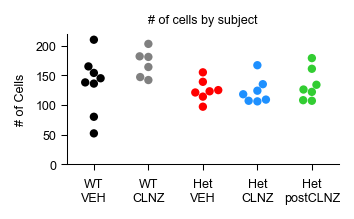

In [10]:
fig, ax = plt.subplots(1,1, figsize=(2.25,1.35), layout = 'constrained')
cell_count =  subject_stage_info_df.groupby([subject_col,'geno_day'])['num_units'].max().reset_index()
sns.swarmplot(data = cell_count,
              x = 'geno_day', y = 'num_units', order = geno_order_w_WT_CLNZ, legend = False, s = 4,**geno_order_w_WT_CLNZ_no_eb)
set_labels(ax, label_dict = dict(title =  f"# of cells by subject", ylim = [0,220],xlabel=None, ylabel= f"# of Cells"))
ax.set_xticklabels([x.get_text().replace(" ", "\n") for x in ax.get_xticklabels()])
save_fig_in_main_fig_dir(fig,fig_name = "Number of cells per subj by geno-day", folder_key='s_1', filetypes_to_save = ['png','svg'])

In [11]:
print(cell_count.info())
cell_count

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35 entries, 0 to 34
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   subject_name  35 non-null     object
 1   geno_day      35 non-null     object
 2   num_units     35 non-null     int64 
dtypes: int64(1), object(2)
memory usage: 972.0+ bytes
None


,subject_name,geno_day,num_units
0,10_3_HET_RS1,Het VEH,97
1,10_3_HET_RS2,Het CLNZ,124
2,10_3_HET_RS3,Het postCLNZ,122
3,13_3_HET_RS1,Het VEH,121
4,13_3_HET_RS2,Het CLNZ,106
5,13_3_HET_RS3,Het postCLNZ,126
6,13_4_WT_RS1,WT VEH,165
7,13_4_WT_RS2,WT CLNZ,147
8,13_5_HET_RS1,Het VEH,114
9,13_5_HET_RS2,Het CLNZ,118


#### Supp. Fig. 1C- % of frames active on average 

In [12]:
trial_event_counts = trial_tseries_df_norm.copy()
trial_event_counts.loc[:,numeric_col] =  trial_event_counts.loc[:,numeric_col] *hyper_param_dict['window_to_bin']
trial_event_counts.loc[:, 'n_events'] = trial_event_counts[numeric_col].sum(axis = 1)
trial_event_counts.loc[:, 'prop_active_frames'] = 100*trial_event_counts.loc[:, 'n_events']/(hyper_param_dict['window_to_bin']*len(numeric_col))
trial_event_counts.tail(3)

,task_phase_vec,IA_RS_vec,corr_err_vec,trial_num,neuron_ID,section,subject_name,session,raw_ID,day,...,num_shuffles,any_enrichment,enriched_in_phase,normalized,max_trial_val_all_time,min_max_type,mean_rate_in_trial,cell_is_active_in_trial,n_events,prop_active_frames
116374,Late_RS,RS,Correct,38,9_3_HET_RS3-213,post_outcome,9_3_HET_RS3,RS3,213,3,...,10000,0.0,False,none,1.0,all_frames,0.00,False,0.0,0.000000
116375,Late_RS,RS,Correct,38,9_3_HET_RS3-214,post_outcome,9_3_HET_RS3,RS3,214,3,...,10000,1.0,True,none,1.0,all_frames,0.15,True,60.0,16.666667
116376,Late_RS,RS,Correct,38,9_3_HET_RS3-215,post_outcome,9_3_HET_RS3,RS3,215,3,...,10000,0.0,False,none,0.8,all_frames,0.00,False,0.0,0.000000


The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\supp_fig_1' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\supp_fig_1\09_Jun_2026' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\date_sorted_figures\09_Jun_2026' already exists.
Saved 1_s_supp_Proportion frames active per trial_posthoc permutation test_09_Jun_2026.csv to C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output
Output saved to C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output\1_s_supp_Proportion frames active per trial_posthoc_text_09_Jun_2026.txt


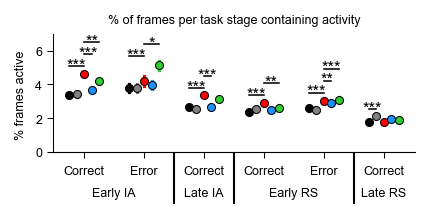

In [13]:
fig,plot_ax = plt.subplots(1,1,figsize = (2.75,1.35), layout = 'constrained')

plot_params =  {'data': trial_event_counts, 
                'errorbar':'se',
                'x':'task_phase_vec',
                'y':'prop_active_frames',
                 'order':stage_chrono_order, 'dodge' :0.5, **geno_color_dict_w_WT_CLNZ}
sc = sns.pointplot(ax = plot_ax, linestyles = 'none', **plot_params, )
ax_title = f"% of frames per task stage containing activity"
set_ax_title_xlabel_ylabel(plot_ax, {'title':ax_title,'ylim': [0, 7], 'ylabel':  '% frames active ', 'xlabel': None, 'legend_false': True})
posthoc_df = main_run_posthoc_tests_and_get_hue_loc_df(plot_ax, plot_params, sc, comparison_list_w_WT_CLNZ, detect_error_bar = True,test_name = 'MWU')
plot_sig_bars_w_comp_df_tight(plot_ax,  posthoc_df.loc[posthoc_df['pvalue'] < 0.05,:])
### ANNOTATOR BLOCK END
ax_add_stage_names_and_outline_points(plot_ax)
posthoc_df['plot_name'] = ax_title
fig_name = f"supp_Proportion frames active per trial" 
save_fig_in_main_fig_dir(fig, fig_name= fig_name, folder_key='s_1', filetypes_to_save = ['png','svg'])
save_plot_record_as_csv_txt(posthoc_df,folder_pref:="1_s",fig_name,csv_folder_most_recent, None, csv_suffix="posthoc permutation test",txt_suffix="posthoc_text")

#### Supp. Fig. 1D- plot mean cella activity including WT CLNZ 

In [14]:
#determine how 'mean_rate' in unit_mean_tseries is calculated

## in trial_series_norm: #get mean of each trial
    # cols_to_get_mean = [c for c in numeric_col]
    # normed_trial_tseries_df['mean_rate'] =normed_trial_tseries_df[cols_to_get_mean].mean(axis = 1) #mean rate is post outcome only

## BUT:     cell_avg_stage_tseries['mean_rate'] = cell_avg_stage_tseries[[c for c in numeric_col_wide if '-' not in c]].mean(axis = 1) #mean rate is post outcome only
trial_event_counts

,task_phase_vec,IA_RS_vec,corr_err_vec,trial_num,neuron_ID,section,subject_name,session,raw_ID,day,...,num_shuffles,any_enrichment,enriched_in_phase,normalized,max_trial_val_all_time,min_max_type,mean_rate_in_trial,cell_is_active_in_trial,n_events,prop_active_frames
0,Early_IA_Correct,IA,Correct,1,10_3_HET_RS1-1,post_outcome,10_3_HET_RS1,RS1,1,1,...,10000,1.0,False,none,1.0,all_frames,0.0000,False,0.0,0.000000
2,Early_IA_Correct,IA,Correct,1,10_3_HET_RS1-3,post_outcome,10_3_HET_RS1,RS1,3,1,...,10000,1.0,False,none,1.0,all_frames,0.0000,False,0.0,0.000000
3,Early_IA_Correct,IA,Correct,1,10_3_HET_RS1-4,post_outcome,10_3_HET_RS1,RS1,4,1,...,10000,1.0,False,none,1.0,all_frames,0.0000,False,0.0,0.000000
4,Early_IA_Correct,IA,Correct,1,10_3_HET_RS1-5,post_outcome,10_3_HET_RS1,RS1,5,1,...,10000,0.0,False,none,1.0,all_frames,0.2900,True,110.0,30.555556
5,Early_IA_Correct,IA,Correct,1,10_3_HET_RS1-6,post_outcome,10_3_HET_RS1,RS1,6,1,...,10000,0.0,False,none,1.0,all_frames,0.0000,False,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
116370,Late_RS,RS,Correct,38,9_3_HET_RS3-209,post_outcome,9_3_HET_RS3,RS3,209,3,...,10000,1.0,False,none,1.0,all_frames,0.0150,True,6.0,1.666667
116373,Late_RS,RS,Correct,38,9_3_HET_RS3-212,post_outcome,9_3_HET_RS3,RS3,212,3,...,10000,2.0,False,none,1.0,all_frames,0.0225,True,9.0,2.500000
116374,Late_RS,RS,Correct,38,9_3_HET_RS3-213,post_outcome,9_3_HET_RS3,RS3,213,3,...,10000,0.0,False,none,1.0,all_frames,0.0000,False,0.0,0.000000
116375,Late_RS,RS,Correct,38,9_3_HET_RS3-214,post_outcome,9_3_HET_RS3,RS3,214,3,...,10000,1.0,True,none,1.0,all_frames,0.1500,True,60.0,16.666667


Saved 1_s_supp_wtclnz_pointplot_Mean event rate by phase_posthoc MWU_09_Jun_2026.csv to C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output
Output saved to C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output\1_s_supp_wtclnz_pointplot_Mean event rate by phase_posthoc_text_09_Jun_2026.txt
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\supp_fig_1' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\supp_fig_1\09_Jun_2026' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\date_sorted_figures\09_Jun_2026' already exists.


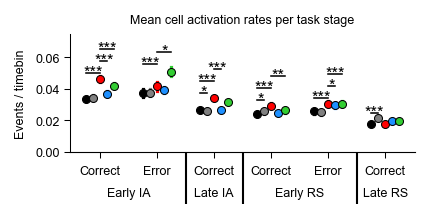

In [15]:
## hue by geno day, rows are task, phases
fig,plot_ax = plt.subplots(1,1,figsize = (2.75,1.35), layout = 'constrained')

plot_params =  {'data': trial_event_counts, 'errorbar':'se', 'x':'task_phase_vec', 'y':'mean_rate_in_trial','orient':'v',
                 'order':phase_list_IA_RS_chrono, 'dodge':0.5, **geno_order_w_WT_CLNZ_no_eb}

sc = sns.pointplot(ax = plot_ax, linestyles = 'none', **plot_params, )
ax_title = f"Mean cell activation rates per task stage"
set_ax_title_xlabel_ylabel(plot_ax, {'title':ax_title,'ylim': [0,0.075], 'ylabel':  'Events / timebin', 'xlabel': None, 'legend_false': True})

posthoc_df = main_run_posthoc_tests_and_get_hue_loc_df(plot_ax, plot_params, sc, comparison_list_w_WT_CLNZ,detect_error_bar = True,test_name = 'MWU')
plot_sig_bars_w_comp_df_tight(plot_ax,  posthoc_df.loc[posthoc_df['pvalue'] < 0.05,:], tight_offset = 0.025)
### ANNOTATOR BLOCK END
ax_add_stage_names_and_outline_points(plot_ax)
posthoc_df['plot_name'] = ax_title
## save figs
fig_name = 'supp'+ f"_wtclnz_pointplot_Mean event rate by phase"
save_plot_record_as_csv_txt(posthoc_df,folder_pref:="1_s",fig_name,csv_folder_most_recent, None,
                                csv_suffix="posthoc MWU",txt_suffix="posthoc_text")

save_fig_in_main_fig_dir(fig, fig_name= fig_name, folder_key='s_1', filetypes_to_save = ['png', 'svg'])


#### Supp. Fig. 1E- WT VEH mean activation

In [16]:
unit_mean_tseries['max_timebin_index'] = unit_mean_tseries.apply(lambda x: list(numeric_col).index(x.max_val_tbin),axis = 1)

The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\fig_2' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\fig_2\09_Jun_2026' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\date_sorted_figures\09_Jun_2026' already exists.


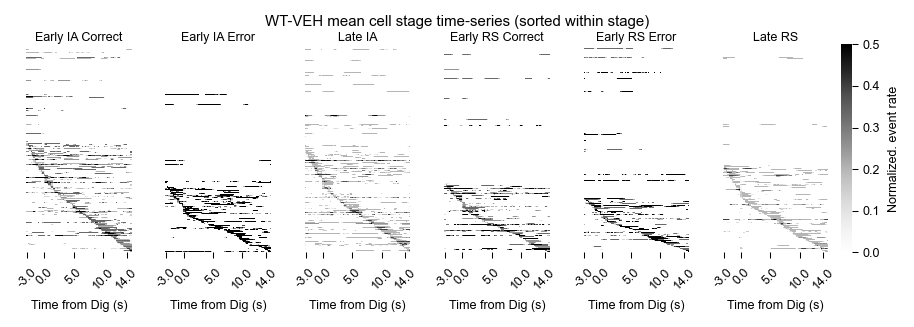

In [17]:
fig, ax_array = plt.subplots(1, len(stage_names), figsize = (6,2), layout = 'constrained', sharex = False, sharey=False,)

tseries_mat = unit_mean_tseries.loc[unit_mean_tseries.geno_day == 'WT VEH',:]
for s, task_stage in enumerate(phase_list_IA_RS_chrono):
    ax_plot = ax_array.flat[s]
    plot_df= tseries_mat.loc[tseries_mat.task_phase_vec == task_stage,:].sort_values(by = 'max_timebin_index', ascending = True).loc[:, numeric_col]
    make_cbar = s in [5]
    sns.heatmap(plot_df, ax = ax_plot,cbar_kws = {'label': f"Normalized. event rate"}, rasterized=True,cbar = make_cbar, vmax = 0.5,cmap = 'Greys',xticklabels=True)
    set_labels(ax_plot, {'title': {'label':task_stage.replace('_', ' '), 'pad':0 },'xlabel': 'Time from Dig (s)'})
    ax_plot.set_yticks([])
    # Extract existing tick labels and positions
    second_tick_to_plot = ['-3.0s','0.0s', '5.0s', '10.0s','14.0s']
    tick_positions = ax_plot.get_xticks()
    tick_labels = [tick.get_text() for tick in ax_plot.get_xticklabels()]
    filtered_ticks = [pos for pos, label in zip(tick_positions, tick_labels) if label.split(" to ")[0] in second_tick_to_plot]# Filter tick positions based on the desired labels
    filtered_labels = [label.split("s to ")[0] for label in tick_labels if label.split(" to ")[0] in second_tick_to_plot]
    # Set the filtered ticks and labels
    ax_plot.set_xticks(filtered_ticks)
    ax_plot.set_xticklabels(filtered_labels, rotation=45, ha='center')
    ax_plot.label_outer()
## save
fig.get_layout_engine().set(w_pad = 0.05, h_pad= 0.01, hspace = 0.00, wspace = 0.00)
figure_title = f"WT-VEH mean cell stage time-series (sorted within stage)"
fig.suptitle(figure_title)
## save fig
fig_name = figure_title
save_fig_in_main_fig_dir(fig, fig_name= fig_name, folder_key=2, filetypes_to_save = ['png','svg'])

#### Supp. Fig. 1F- neural stage-activation matrix with WT CLNZ include 

The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\supp_fig_1' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\supp_fig_1\09_Jun_2026' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\date_sorted_figures\09_Jun_2026' already exists.


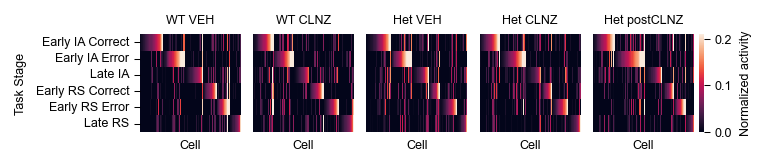

In [18]:
#plot unit heatmap for ALL GENOS
fig_mean_activity, axes = plt.subplots(1,5,figsize = (5,1), layout = 'constrained')
activity_type =  f"Normalized activity"
heatmap_clabel = activity_type

for count, geno in enumerate(geno_order_w_WT_CLNZ):
    plot_mask = (AV_matrix.geno_day == geno) & has_Early_IA_Error
    plot_data = AV_matrix.sort_values(by = ['max_phase','max_phase_val'],ascending = True).loc[plot_mask, stage_chrono_order].T
    plot_heatmap_w_kwargs(data =plot_data.rename(index = {p:p.replace('_', ' ') for p in plot_data.index}), ax =axes.flat[count],
                          kwarg_dict = {
                              'vmin': min_5th_quantile, 'vmax':max_95th_quantile, 'cbar_kws': {'label': heatmap_clabel},
                              'cbar': {True: True, False: False}[count == len(geno_order_w_WT_CLNZ)-1], 'yticklabels': True, 'xticklabels':False},
                          label_dict = {'xlabel': f"Cell", 'ylabel': {False:"Task Stage", True: None}[count > 0], 'title': geno})#plot heatmap
    axes.flat[count].set_yticks({True:[], False: axes.flat[count].get_yticks()}[count > 0])
#save figs
fig_prefix = "supp_" #for sorting in folder
fig_name = 'one_row_cell stage-activity sorted heatmap'
fig_mean_activity.get_axes()
save_fig_in_main_fig_dir(fig_mean_activity, fig_name= fig_name, folder_key='s_1', filetypes_to_save = ['png', 'svg'])

#### Get enrichment stats

In [19]:
unique_ID_enrichment_df = unit_mean_tseries.groupby(by = ['geno_day', unit_ID_col])[stage_names].first()
# bin_ends = get_numeric_col_bin_end_float(numeric_col)
geno_mean_enrich = unique_ID_enrichment_df.groupby('geno_day').agg({ **{p: 'mean' for p in stage_names}}).reset_index().melt(id_vars = 'geno_day', var_name = 'phase', value_name = '% enriched')
geno_mean_enrich.head()

#get long df where each row = 1 unique CELL ID and the # of stage's its enriched in
cell_num_stage_enriched_df_long = unique_ID_enrichment_df[stage_names].sum(axis = 1).sort_values().reset_index().rename(columns = {0: 'num_enrich'})
geno_cell_n_enrich_df_wide = cell_num_stage_enriched_df_long.pivot_table(columns = 'num_enrich', index =  'geno_day', aggfunc = 'count').fillna(0).divide(n_total_units, axis = 0)#pivot this to wide and collect the count of datasets doing this
geno_cell_n_enrich_df_wide.columns = geno_cell_n_enrich_df_wide.columns.get_level_values(1)
prop_of_cells_enrich_n_stages = geno_cell_n_enrich_df_wide.reset_index().melt(id_vars = 'geno_day', var_name = 'num_enrich', value_name = 'prop_enrich')
prop_of_cells_enrich_n_stages.head()

,geno_day,num_enrich,prop_enrich
0,Het CLNZ,0.0,0.632794
1,Het VEH,0.0,0.636156
2,Het postCLNZ,0.0,0.600854
3,WT CLNZ,0.0,0.650638
4,WT VEH,0.0,0.669444


#### Supp. Fig.1G- % of cells enriched for stages

The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\supp_fig_1' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\supp_fig_1\09_Jun_2026' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\date_sorted_figures\09_Jun_2026' already exists.


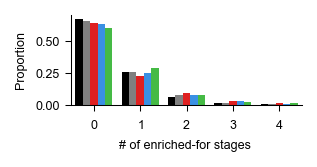

In [20]:


##plot the distribution of values + WT CLNZ
fig, ax = plt.subplots(1,1, figsize = (2,1), layout = 'constrained')
sns.barplot(prop_of_cells_enrich_n_stages, x = 'num_enrich',  y = 'prop_enrich',  **format_no_eb_w_WT_CLNZ) ## tune params
set_ax_title_xlabel_ylabel(ax, label_dict = {'title': None, 'xlim': [-0.5, 4.5], 'ylabel': f"Proportion", 'legend_false': True, 'xlabel': "# of enriched-for stages "})
make_legend = False
ax.xaxis.set_major_formatter(matplotlib.ticker.ScalarFormatter(useMathText=True))

if make_legend:
    hand, labs = ax.get_legend_handles_labels() #pull legend from final PCA object and delete it
    fig.legend(hand, labs, bbox_to_anchor=(0.55, 1.0),loc = 'lower center', ncols = 5, frameon = True, title = 'Genotype-treatment', **legend_defaults)
#save figure
fig_prefix = "supplement_enrich_" #for sorting in folder
fig_name = "Distrib of stage enrichment count by geno-day + WT_CLNZ"
save_fig_in_main_fig_dir(fig, fig_name= fig_name, folder_key='s_1', filetypes_to_save = ['png', 'svg'])

#### Supp. Fig.1H: Cell enrichment plots (including WT CLNZ % enriched by stage)

The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\supp_fig_1' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\supp_fig_1\09_Jun_2026' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\date_sorted_figures\09_Jun_2026' already exists.


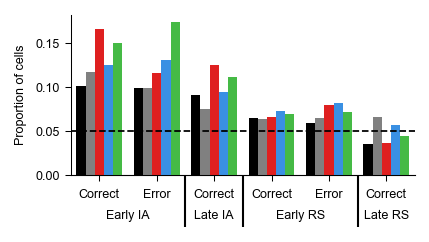

In [21]:
## plot distib of # enriched units by phase
fig, ax_prop_enrich = plt.subplots(1,1, figsize = (2.75,1.5), layout = 'constrained')
g = sns.barplot(ax =ax_prop_enrich, data =geno_mean_enrich, order = phase_list_IA_RS_chrono, x = 'phase', y = '% enriched',  **geno_color_dict_w_WT_CLNZ)
ax_prop_enrich.axhline(y = 0.05, color = 'black', linestyle = '--')
set_ax_title_xlabel_ylabel(ax_prop_enrich, {'title': None,'ylim': [0, None],'legend_false':True,  'ylabel':  f"Proportion of cells", 'xlabel': None})#f"Task Stage"}) #f' Prop. of cells active > shuffle 95%ile'
## given ordering of xposition, get the list of what ticks are belonging to what task stage
sec, sec2, is_dict = set_stage_xticks_2_layer(ax_prop_enrich, phase_list_IA_RS_chrono)
#####save fig
fig_prefix = "supplement_enrich_" #for sorting in folder
fig_name =  "% cell stage-enriched barplot_with_WT_CLNZ"
save_fig_in_main_fig_dir(fig, fig_name= fig_name, folder_key='s_1', filetypes_to_save = ['png','svg'])

#### Supp Fig 1G_H combined: Enrichment 


The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\supp_fig_1' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\supp_fig_1\09_Jun_2026' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\date_sorted_figures\09_Jun_2026' already exists.


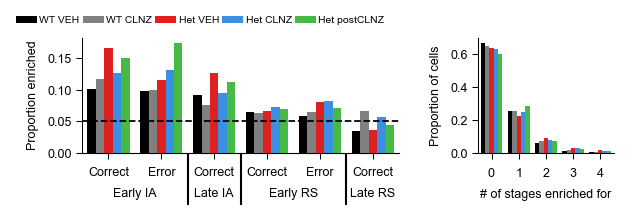

In [22]:

fig, axes = plt.subplots(1,2, figsize = (4.,1.2), layout = 'constrained', width_ratios = [0.7, 0.3], gridspec_kw = dict(wspace = 0.1))

## plot distib of # enriched units by phase
ax_prop_enrich = axes[0]
g = sns.barplot(ax =ax_prop_enrich, data =geno_mean_enrich, x = 'phase', y = '% enriched',order = phase_list_IA_RS_chrono, **geno_color_dict_w_WT_CLNZ)
ax_prop_enrich.axhline(y = 0.05, color = 'black', linestyle = '--')
sec, sec2, is_dict = set_stage_xticks_2_layer(ax_prop_enrich, phase_list_IA_RS_chrono) ## given ordering of xposition, get the list of what ticks are belonging to what task stage
set_ax_title_xlabel_ylabel(ax_prop_enrich, {'title': None,'ylim': [0, None], 'legend_false':True, 'ylabel':  f"Proportion enriched", 'xlabel': None})#f"Task Stage"}) #f' Prop. of cells active > shuffle 95%ile'

##plot the distribution of values
ax_barplot = axes[1]
sns.barplot(ax = ax_barplot, data= prop_of_cells_enrich_n_stages, x = 'num_enrich',  y = 'prop_enrich',  **format_no_eb_w_WT_CLNZ) ## tune params
set_ax_title_xlabel_ylabel(ax_barplot, label_dict = {'title': None, 'xlim': [-0.5, 4.5], 'ylabel': f"Proportion of cells", 'legend_false':True,'xlabel': "# of stages enriched for"})
ax_barplot.xaxis.set_major_formatter(matplotlib.ticker.ScalarFormatter(useMathText=True))
hand, labs = ax_barplot.get_legend_handles_labels() #pull legend from final object and delete it
fig.legend(hand, labs, bbox_to_anchor=(0.3, 1.0),loc = 'lower center', ncols =5, frameon = False, title =None, **legend_defaults)

#####save fig
fig_name =  r"supplement enriched stage & % enriched by stage_ barplot"
save_fig_in_main_fig_dir(fig, fig_name= fig_name, folder_key='s_1', filetypes_to_save = ['svg','png'],bbox_inches="tight",pad_inches=0)

In [23]:
prop_of_cells_enrich_n_stages

,geno_day,num_enrich,prop_enrich
0,Het CLNZ,0.0,0.632794
1,Het VEH,0.0,0.636156
2,Het postCLNZ,0.0,0.600854
3,WT CLNZ,0.0,0.650638
4,WT VEH,0.0,0.669444
5,Het CLNZ,1.0,0.247113
6,Het VEH,1.0,0.221968
7,Het postCLNZ,1.0,0.283885
8,WT CLNZ,1.0,0.255152
9,WT VEH,1.0,0.254630


In [24]:
print(range(5))
for i in range(6):
    print(i)
    df = prop_of_cells_enrich_n_stages.loc[prop_of_cells_enrich_n_stages.num_enrich == i].copy()
    df.prop_enrich = df.prop_enrich * 100
    for r in df.itertuples():
        print(f"{r.geno_day}: {round(r.prop_enrich,1)}")

range(0, 5)
0
Het CLNZ: 63.3
Het VEH: 63.6
Het postCLNZ: 60.1
WT CLNZ: 65.1
WT VEH: 66.9
1
Het CLNZ: 24.7
Het VEH: 22.2
Het postCLNZ: 28.4
WT CLNZ: 25.5
WT VEH: 25.5
2
Het CLNZ: 8.0
Het VEH: 9.3
Het postCLNZ: 7.5
WT CLNZ: 7.5
WT VEH: 5.8
3
Het CLNZ: 2.8
Het VEH: 3.2
Het postCLNZ: 2.3
WT CLNZ: 1.5
WT VEH: 1.2
4
Het CLNZ: 0.9
Het VEH: 1.5
Het postCLNZ: 1.3
WT CLNZ: 0.4
WT VEH: 0.4
5
Het CLNZ: 0.3
Het VEH: 0.2
Het postCLNZ: 0.4
WT CLNZ: 0.1
WT VEH: 0.2


#### Supp. Fig. 1I- WT CLNZ tSNE projection

The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\supp_fig_1' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\supp_fig_1\09_Jun_2026' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\date_sorted_figures\09_Jun_2026' already exists.


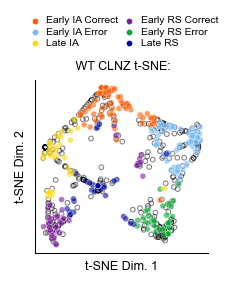

In [25]:
tsne_figsize = (1.5,1.5)
fig,ax =plt.subplots(1,1,figsize = tsne_figsize, layout = 'constrained')
transform = f"t-SNE"
## make plot
geno = 'WT CLNZ'
plot_params = dict( x = 'dim_1', y = 'dim_2',hue = 'ensemble',ax = ax) #constant across both scatters
#plot nonenriched
non_ensemble_df =  tsne_results[geno].loc[tsne_results[geno].ensemble == 'none',:]
sns.scatterplot(**plot_params, data =non_ensemble_df,   s = 5,alpha = 0.5, linewidth =0.5, legend = False, palette = ['black'],  zorder=-1000)
#find collections with > 1 point contained therein
nonlegend_collections = [x for x in ax.collections if x.get_facecolors().shape[0]>1]
collection_size= [x.get_facecolors().shape for x in nonlegend_collections]
largest_collection_size = np.max(collection_size) #use largest collection as == ensemble 
non_enrich_collection = [x for x in nonlegend_collections if x.get_facecolors().shape[0] == largest_collection_size][0]
non_enrich_collection.set_edgecolors(non_enrich_collection.get_facecolors().copy())# Restore the edge colors using the saved values
non_enrich_collection.set_facecolors("none")# Remove the face color by setting it to "none"
#plot ensemble
ensemble_df = tsne_results[geno].loc[tsne_results[geno].ensemble.isin(stage_chrono_order),:]
sns.scatterplot(**plot_params, data =ensemble_df, s = 8,alpha = 0.6, legend = True, palette = [stage_palette_dict[x] for x in stage_chrono_order], hue_order =stage_chrono_order,zorder=100 )
set_ax_title_xlabel_ylabel(ax,{'title': f" {geno} {transform}:",'ylabel': f'{transform} Dim. 2', 'xlabel': f'{transform} Dim. 1', 'xticks':[], 'yticks':[]})
#get legend and move
hand, labels = ax.get_legend_handles_labels()
ax.get_legend().remove()
fig.legend(hand, [x.replace('_', ' ') for x in labels], bbox_to_anchor=(0.5, 1),loc = 'lower center', ncol = 2, frameon = False, title = None, handletextpad=0.1, )
#save fig 
ax.set_box_aspect(1)
fig_name =  f"WT CLNZ TSNE- stage activity matrix"
save_fig_in_main_fig_dir(fig, fig_name= fig_name, folder_key='s_1', filetypes_to_save = ['png','svg'])

#### Supp. Fig. 1J- plot % ensemble v nonensemble cells active on each trial

In [26]:
trial_tseries_df_norm.columns

Index(['task_phase_vec', 'IA_RS_vec', 'corr_err_vec', 'trial_num', 'neuron_ID',
       'section', 'subject_name', 'session', 'raw_ID', 'day',
       ...
       'pvalue_post_outcome_Late_RS', 'Run_end_time', 'num_shuffles',
       'any_enrichment', 'enriched_in_phase', 'normalized',
       'max_trial_val_all_time', 'min_max_type', 'mean_rate_in_trial',
       'cell_is_active_in_trial'],
      dtype='object', length=105)

Saved 1_s_Mean % of cells active in stage that are in stage ensemble_posthoc MWU_09_Jun_2026.csv to C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output
Output saved to C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output\1_s_Mean % of cells active in stage that are in stage ensemble_posthoc_text_09_Jun_2026.txt
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\supp_fig_1' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\supp_fig_1\09_Jun_2026' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\date_sorted_figures\09_Jun_2026' already exists.


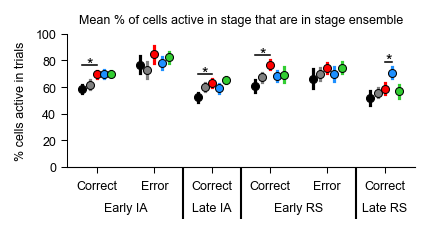

In [27]:
prop_cell_active_in_trial = trial_tseries_df_norm.groupby(by = [subject_col, 'geno_day', 'trial_num', 'task_phase_vec', 'enriched_in_phase'])[['cell_is_active_in_trial']].mean().reset_index() #active in trial is, cell I is active in trial N
## plot % fo cells active by each ensemble embership
fig,plot_ax = plt.subplots(1,1,figsize = (2.75,1.45), layout = 'constrained')
e_stat_str = {True:'enriched', False: 'non-enriched'}
e_stat = 1.0
plot_mask = prop_cell_active_in_trial.enriched_in_phase == e_stat
#make plot 
plot_df = prop_cell_active_in_trial.loc[plot_mask,:].copy()
plot_df['cell_is_active_in_trial'] = plot_df['cell_is_active_in_trial']*100

plot_params =  {'data': plot_df,  'x':'task_phase_vec', 'y':'cell_is_active_in_trial','orient':'v',
                 'order':stage_chrono_order, 'dodge': 0.5, **geno_order_w_WT_CLNZ_no_eb}
sc = sns.pointplot(ax = plot_ax, linestyles = 'none', **plot_params, errorbar = 'se')
ax_title = f"Mean % of cells active in stage that are in stage ensemble"
set_ax_title_xlabel_ylabel(plot_ax, {'title':ax_title,
                                     'ylabel':  '% cells active in trials', 
                                     'xlabel': None,
                                     'ylim': [0, 100],
                                     'legend_false': True})
posthoc_df = main_run_posthoc_tests_and_get_hue_loc_df(plot_ax, plot_params, sc, comparison_list_w_WT_CLNZ,test_name = 'MWU',detect_error_bar=True)
plot_sig_bars_w_comp_df_tight(plot_ax,  posthoc_df.loc[posthoc_df['pvalue'] < 0.05,:])
### ANNOTATOR BLOCK END
ax_add_stage_names_and_outline_points(plot_ax)
posthoc_df['plot_name'] = ax_title
#save csv
save_plot_record_as_csv_txt(posthoc_df,folder_pref:="1_s",ax_title,csv_folder_most_recent, None, csv_suffix="posthoc MWU",txt_suffix="posthoc_text")
fig_name = f"supp_Prop stage-active cell in stage ensemble" 
save_fig_in_main_fig_dir(fig, fig_name= fig_name, folder_key='s_1', filetypes_to_save = ['png','svg'])

#### Supp. Fig. 1K: # of cells present in each ensemble (added for revision)

In [28]:
subject_col = 'subject_name'
unit_ID_col = 'neuron_ID'
non_ens_col = 'Non_Ensemble'

## add flag for if cell is not enriched in any stage
neuron_enrichment =  trial_tseries_df_norm.groupby([subject_col, 'geno_day', unit_ID_col])[stage_names].mean()
neuron_enrichment[non_ens_col] = (neuron_enrichment.sum(axis = 1) == 0).astype(int)
phase_enrichment_by_subj = neuron_enrichment.reset_index().loc[:, list(stage_names) + [non_ens_col, subject_col, 'geno_day']].groupby(by = [subject_col, 'geno_day']).sum().reset_index()
phase_enrichment_by_subj['subject_id'] = phase_enrichment_by_subj['subject_name'].apply(lambda x: "_".join(x.split("_")[0:2]))

phase_enrichment_by_subj

,subject_name,geno_day,Early_IA_Correct,Early_IA_Error,Early_RS_Correct,Early_RS_Error,Late_IA,Late_RS,Non_Ensemble,subject_id
0,10_3_HET_RS1,Het VEH,19.0,10.0,9.0,8.0,13.0,5.0,64,10_3
1,10_3_HET_RS2,Het CLNZ,21.0,0.0,11.0,14.0,12.0,7.0,81,10_3
2,10_3_HET_RS3,Het postCLNZ,25.0,0.0,13.0,16.0,18.0,9.0,76,10_3
3,13_3_HET_RS1,Het VEH,19.0,27.0,10.0,8.0,15.0,6.0,69,13_3
4,13_3_HET_RS2,Het CLNZ,13.0,19.0,11.0,13.0,13.0,12.0,60,13_3
5,13_3_HET_RS3,Het postCLNZ,17.0,0.0,8.0,13.0,15.0,11.0,84,13_3
6,13_4_WT_RS1,WT VEH,16.0,13.0,8.0,5.0,15.0,3.0,118,13_4
7,13_4_WT_RS2,WT CLNZ,14.0,10.0,10.0,21.0,8.0,7.0,92,13_4
8,13_5_HET_RS1,Het VEH,9.0,12.0,4.0,10.0,13.0,2.0,79,13_5
9,13_5_HET_RS2,Het CLNZ,9.0,15.0,6.0,3.0,5.0,6.0,80,13_5


The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\supp_fig_1' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\supp_fig_1\09_Jun_2026' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\date_sorted_figures\09_Jun_2026' already exists.


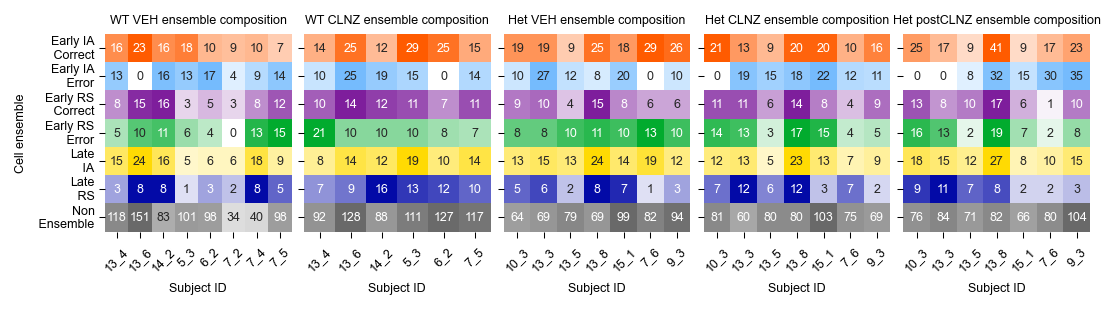

In [29]:
from matplotlib.colors import LinearSegmentedColormap

# 1. Build a per-row colormap dict (white → stage color)
row_cmap_dict = {
    stage: LinearSegmentedColormap.from_list(stage, ['white', color])
    for stage, color in stage_palette_dict.items()
}
row_cmap_dict['Non_Ensemble'] = LinearSegmentedColormap.from_list(
    'Non_Ensemble', ['white', 'dimgrey']
)

fig, axes = plt.subplots(1,5, figsize = (7.25,1.95), layout = 'constrained')

# 2. Replace the single sns.heatmap call with a per-row loop
for g, geno in enumerate(geno_order_w_WT_CLNZ):
    ax = axes.flat[g]
    geno_mask = phase_enrichment_by_subj['geno_day'] == geno
    geno_df = phase_enrichment_by_subj[geno_mask]
    heatmap_data = geno_df.set_index('subject_id').loc[:, stage_names + [non_ens_col]].T

    ## NEW- add a total column to the right of the heatmap data for annotation purposes, but not to be plotted
    row_labels = list(heatmap_data.index)
    for row_idx, row_name in enumerate(row_labels):
        # Mask everything except this row
        mask = np.ones_like(heatmap_data.values, dtype=bool)
        mask[row_idx, :] = False

        sns.heatmap(heatmap_data, ax=ax, mask=mask,
            cmap=row_cmap_dict[row_name],
            annot=True, fmt='.0f', cbar=False,
            vmin=0, vmax=heatmap_data.iloc[row_idx].max(),
        )
        ## annotate lims
    set_labels(ax = ax, label_dict= {'title': f'{geno} ensemble composition', 
    'ylabel': ('Cell ensemble' if g==0 else None), 'xlabel': 'Subject ID'})

    ax.set_xticklabels([x.get_text()for x in ax.get_xticklabels()], rotation = 45)
    if g == 0:
        ax.set_yticklabels([y.get_text().replace('Early_IA', 'Early IA').replace("Early_RS", "Early RS").replace("_", "\n ") for y in ax.get_yticklabels()],
                            rotation = 0,);
    else:
        ax.set_yticklabels([])
        #remove ytick spines 
        ax.spines['left'].set_visible(False)

## save fig
fig_name = '# of subject cells per ens'
save_fig_in_main_fig_dir(fig, fig_name= fig_name, folder_key='s_1', filetypes_to_save = ['png', 'svg'])

The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\supp_fig_1' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\supp_fig_1\09_Jun_2026' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\date_sorted_figures\09_Jun_2026' already exists.


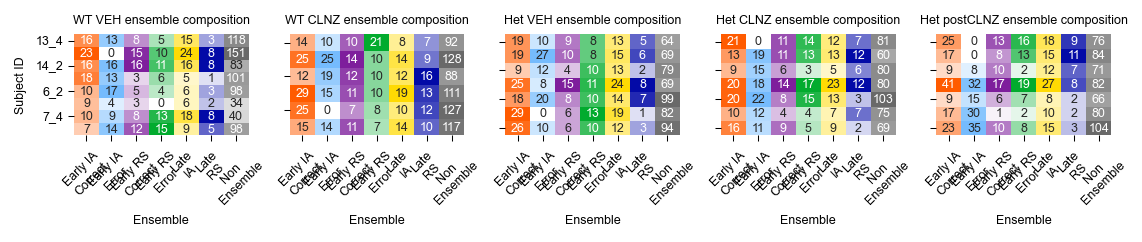

In [30]:
from matplotlib.colors import LinearSegmentedColormap

# 1. Build a per-column colormap dict (white → stage color)
row_cmap_dict = {
    stage: LinearSegmentedColormap.from_list(stage, ['white', color])
    for stage, color in stage_palette_dict.items()
}
row_cmap_dict['Non_Ensemble'] = LinearSegmentedColormap.from_list(
    'Non_Ensemble', ['white', 'dimgrey']
)

fig, axes = plt.subplots(1,5, figsize = (7.5,1.5), layout = 'constrained')

# 2. Per-column loop (ensembles on x-axis, subjects on y-axis)
for g, geno in enumerate(geno_order_w_WT_CLNZ):
    ax = axes.flat[g]
    geno_mask = phase_enrichment_by_subj['geno_day'] == geno
    geno_df = phase_enrichment_by_subj[geno_mask]
    heatmap_data = geno_df.set_index('subject_id').loc[:, stage_names + [non_ens_col]]

    col_labels = list(heatmap_data.columns)
    for col_idx, col_name in enumerate(col_labels):
        # Mask everything except this column
        mask = np.ones_like(heatmap_data.values, dtype=bool)
        mask[:, col_idx] = False

        sns.heatmap(heatmap_data, ax=ax, mask=mask,
            cmap=row_cmap_dict[col_name],
            annot=True, fmt='.0f', cbar=False,
            vmin=0, vmax=heatmap_data.iloc[:, col_idx].max(),
        )
    set_labels(ax = ax, label_dict= {'title': f'{geno} ensemble composition', 
        'ylabel': ('Subject ID' if g==0 else None), 'xlabel': 'Ensemble'})

    ax.set_xticklabels([x.get_text().replace('Early_IA', 'Early IA').replace("Early_RS", "Early RS").replace("_", "\n") for x in ax.get_xticklabels()], rotation = 45)
    if g == 0:
        ax.set_yticklabels([y.get_text() for y in ax.get_yticklabels()], rotation = 0)
    else:
        ax.set_yticklabels([])

## save fig
fig_name = '# of subject cells per ens_pivoted'
save_fig_in_main_fig_dir(fig, fig_name= fig_name, folder_key='s_1', filetypes_to_save = ['png', 'svg'])


The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\supp_fig_1' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\supp_fig_1\09_Jun_2026' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\date_sorted_figures\09_Jun_2026' already exists.


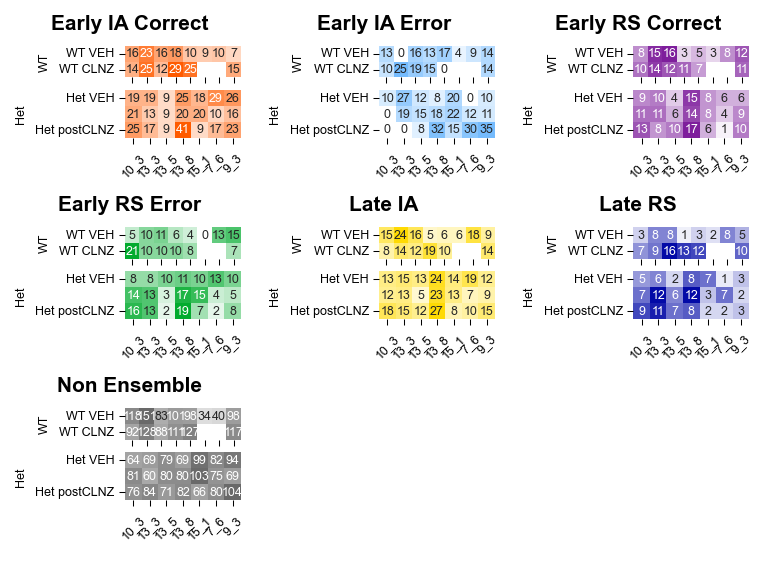

In [31]:
import math
from matplotlib.colors import LinearSegmentedColormap

# Build per-stage colormap dict (white → stage color)
stage_cmap_dict = {
    stage: LinearSegmentedColormap.from_list(stage, ['white', color])
    for stage, color in stage_palette_dict.items()
}
stage_cmap_dict['Non_Ensemble'] = LinearSegmentedColormap.from_list(
    'Non_Ensemble', ['white', 'dimgrey']
)

# Define WT vs HET groupings
geno_groups = {
    'WT': [gd for gd in geno_order_w_WT_CLNZ if gd.startswith('WT')],
    'Het': [gd for gd in geno_order_w_WT_CLNZ if gd.startswith('Het')],
}
height_ratios = [len(gds) for gds in geno_groups.values()]

all_stages = list(stage_names) + [non_ens_col]
stages_per_row = 3
n_fig_rows = math.ceil(len(all_stages) / stages_per_row)

fig = plt.figure(figsize=(5, n_fig_rows * 1.2), layout='constrained')
subfigs = fig.subfigures(n_fig_rows, stages_per_row, wspace=0.05)

for stage_idx, stage in enumerate(all_stages):
    r = stage_idx // stages_per_row
    c = stage_idx % stages_per_row
    sf = subfigs[r, c]

    stage_label = stage.replace('Early_IA', 'Early IA').replace('Early_RS', 'Early RS').replace('_', ' ')
    sf.suptitle(stage_label, fontweight='bold', fontsize=10)

    axes = sf.subplots(len(geno_groups), 1, gridspec_kw={'height_ratios': height_ratios})

    for geno_idx, (geno_label, geno_days) in enumerate(geno_groups.items()):
        ax = axes[geno_idx]

        group_df = phase_enrichment_by_subj[
            phase_enrichment_by_subj['geno_day'].isin(geno_days)
        ]
        heatmap_data = group_df.pivot(
            index='subject_id', columns='geno_day', values=stage
        ).reindex(columns=geno_days).sort_index().T

        vmax_val = heatmap_data.max().max()
        if pd.isna(vmax_val) or vmax_val == 0:
            vmax_val = 1

        sns.heatmap(heatmap_data, ax=ax,
            cmap=stage_cmap_dict[stage],
            annot=True, fmt='.0f', cbar=False,
            vmin=0, vmax=vmax_val,
        )

        ax.set_ylabel(geno_label)
        ax.set_yticklabels([y.get_text() for y in ax.get_yticklabels()], rotation=0)

        # X-axis: subject labels on bottom subplot only
        if geno_idx < len(geno_groups) - 1:
            ax.set_xticklabels([])
        else:
            ax.set_xticklabels([x.get_text() for x in ax.get_xticklabels()], rotation=45)
        ax.set_xlabel('')

fig_name = '# of subject cells per ens - by stage x geno'
save_fig_in_main_fig_dir(fig, fig_name=fig_name, folder_key='s_1', filetypes_to_save=['png', 'svg'])

## Figure 2 plots

#### Figure 2E- matrix of cell mean activity by task stage (dropping cells with no Early IA Error trials)

The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\fig_2' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\fig_2\09_Jun_2026' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\date_sorted_figures\09_Jun_2026' already exists.


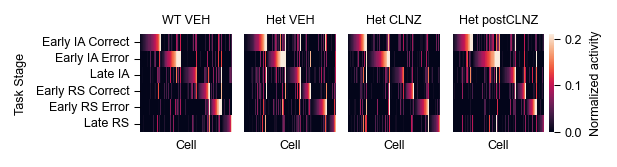

In [32]:
#plot unit heatmap for ALL GENOS
fig_mean_activity, axes = plt.subplots(1,4,figsize = (4,1), layout = 'constrained')
heatmap_clabel =  f"Normalized activity"

for count, geno in enumerate(geno_order):
    plot_mask = (AV_matrix.geno_day == geno) & has_Early_IA_Error
    plot_data = AV_matrix.sort_values(by = ['max_phase','max_phase_val'],ascending = True).loc[plot_mask, stage_chrono_order].T
    plot_heatmap_w_kwargs(data =plot_data.rename(index = {p:p.replace('_', ' ') for p in plot_data.index}), ax =axes.flat[count],
                          kwarg_dict = { 'vmin': min_5th_quantile, 'vmax':max_95th_quantile, 'cbar_kws': {'label': heatmap_clabel},
                              'cbar': {True: True, False: False}[count == len(geno_order)-1], 'yticklabels': True, 'xticklabels':False},
                          label_dict = {'xlabel': f"Cell", 'ylabel': {False:"Task Stage", True: None}[count > 0], 'title': geno})
    axes.flat[count].set_yticks({True:[], False: axes.flat[count].get_yticks()}[count > 0])
#save figs
fig_name = 'one_row_cell stage-activity sorted heatmap'
# fig_mean_activity.get_axes()
save_fig_in_main_fig_dir(fig_mean_activity, fig_name= fig_name, folder_key=2, filetypes_to_save = ['png', 'svg'])

#### Figure 2 H- TSNE projection of (mean stage activity) x (cell_ID) with Ensemble

The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\fig_2' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\fig_2\09_Jun_2026' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\date_sorted_figures\09_Jun_2026' already exists.


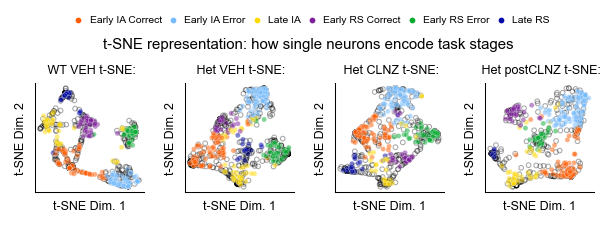

In [33]:
tsne_figsize = (4.,1.25)
fig,ax_array =plt.subplots(1,4,figsize = tsne_figsize, layout = 'constrained')
transform = f"t-SNE"
fig.suptitle(f"t-SNE representation: how single neurons encode task stages")
## make plot
for geno_count, geno in enumerate(geno_order):#iterate through AVs to project TSNE
    ax = ax_array.flat[geno_count]
    plot_params = dict( x = 'dim_1', y = 'dim_2',hue = 'ensemble',ax = ax) #constant across both scatters
    #plot nonenriched
    non_ens_ax = ax_array.flat[geno_count]
    non_ensemble_df =  tsne_results[geno].loc[tsne_results[geno].ensemble == 'none',:]
    sns.scatterplot(**plot_params, data =non_ensemble_df,   s = 5,alpha = 0.35, linewidth =0.5, legend = False, palette = ['black'],  zorder=0)
    #find collections with > 1 point contained therein
    nonlegend_collections = [x for x in non_ens_ax.collections if x.get_facecolors().shape[0]>1]
    collection_size= [x.get_facecolors().shape for x in nonlegend_collections]
    largest_collection_size = np.max(collection_size) #use largest collection as == ensemble 
    non_enrich_collection = [x for x in nonlegend_collections if x.get_facecolors().shape[0] == largest_collection_size][0]
    non_enrich_collection.set_edgecolors(non_enrich_collection.get_facecolors().copy())# Restore the edge colors using the saved values
    non_enrich_collection.set_facecolors("none")# Remove the face color by setting it to "none"
    make_legend = geno_count == len(geno_order)-1
    
    #plot ensemble
    ensemble_df = tsne_results[geno].loc[tsne_results[geno].ensemble.isin(stage_chrono_order),:]
    sns.scatterplot(**plot_params, data =ensemble_df, s = 6,alpha = 0.5, legend = make_legend, palette = [stage_palette_dict[x] for x in stage_chrono_order], hue_order =stage_chrono_order,zorder=100 )
    set_ax_title_xlabel_ylabel(ax,{'title': f" {geno} {transform}:",'ylabel': f'{transform} Dim. 2', 'xlabel': f'{transform} Dim. 1', 'xticks':[], 'yticks':[]})
    
#get legend and move
hand, labels = ax_array.flat[-1].get_legend_handles_labels()
ax_array.flat[-1].get_legend().remove()
fig.legend(hand, [x.replace('_', ' ') for x in labels], bbox_to_anchor=(0.5, 1),loc = 'lower center', ncol = 7, frameon = False, title = None, handletextpad=0.1, )
#save fig 
for ax in ax_array.flat:# force each subplot’s BOX to be square:
    ax.set_box_aspect(1)
fig_name =  f"all summary TSNE- {transform} ens mean act in task stage"

save_fig_in_main_fig_dir(fig, fig_name= fig_name, folder_key=2, filetypes_to_save = ['png', 'svg'])

#### Figure 2F & G- % of cells enriched for each stage, and # of stages enriched for


In [34]:
unique_ID_enrichment_df = unit_mean_tseries.groupby(by = ['geno_day', unit_ID_col])[stage_names].first()
# bin_ends = get_numeric_col_bin_end_float(numeric_col)
geno_mean_enrich = unique_ID_enrichment_df.groupby('geno_day').agg({ **{p: 'mean' for p in stage_names}}).reset_index().melt(id_vars = 'geno_day', var_name = 'phase', value_name = r'% enriched')
geno_mean_enrich.head()

,geno_day,phase,% enriched
0,Het CLNZ,Early_IA_Correct,0.125866
1,Het VEH,Early_IA_Correct,0.165904
2,Het postCLNZ,Early_IA_Correct,0.150480
3,WT CLNZ,Early_IA_Correct,0.117763
4,WT VEH,Early_IA_Correct,0.100926


The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\fig_2' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\fig_2\09_Jun_2026' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\date_sorted_figures\09_Jun_2026' already exists.


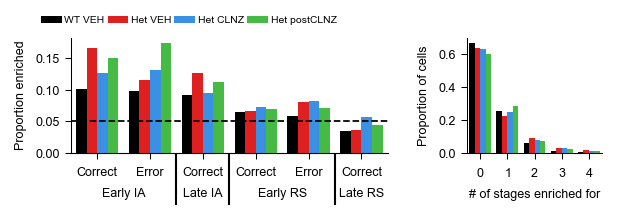

In [35]:

fig, axes = plt.subplots(1,2, figsize = (4.,1.2), layout = 'constrained', width_ratios = [0.7, 0.3], gridspec_kw = dict(wspace = 0.1))

## plot distib of # enriched units by phase
ax_prop_enrich = axes[0]
g = sns.barplot(ax =ax_prop_enrich, data =geno_mean_enrich, x = 'phase', y = '% enriched',order = phase_list_IA_RS_chrono, **geno_color_dict)
ax_prop_enrich.axhline(y = 0.05, color = 'black', linestyle = '--')
sec, sec2, is_dict = set_stage_xticks_2_layer(ax_prop_enrich, phase_list_IA_RS_chrono) ## given ordering of xposition, get the list of what ticks are belonging to what task stage
set_ax_title_xlabel_ylabel(ax_prop_enrich, {'title': None,'ylim': [0, None], 'legend_false':True, 'ylabel':  f"Proportion enriched", 'xlabel': None})#f"Task Stage"}) #f' Prop. of cells active > shuffle 95%ile'

##plot the distribution of values
ax_barplot = axes[1]
sns.barplot(ax = ax_barplot, data= prop_of_cells_enrich_n_stages, x = 'num_enrich',  y = 'prop_enrich',  **geno_color_dict_no_errorbar) ## tune params
set_ax_title_xlabel_ylabel(ax_barplot, label_dict = {'title': None, 'xlim': [-0.5, 4.5], 'ylabel': f"Proportion of cells", 'legend_false':True,'xlabel': "# of stages enriched for"})
ax_barplot.xaxis.set_major_formatter(matplotlib.ticker.ScalarFormatter(useMathText=True))
hand, labs = ax_barplot.get_legend_handles_labels() #pull legend from final PCA object and delete it
fig.legend(hand, labs, bbox_to_anchor=(0.3, 1.0),loc = 'lower center', ncols =4, frameon = False, title =None, **legend_defaults)

#####save fig
fig_name =  r"Figure 2F & G- # enriched stage & % enriched by stage_ barplot"
save_fig_in_main_fig_dir(fig, fig_name= fig_name, folder_key=2, filetypes_to_save = ['svg','png'],bbox_inches="tight",pad_inches=0)

In [36]:
enrichment_counts = pd.pivot(prop_of_cells_enrich_n_stages, columns = 'num_enrich', index = 'geno_day', values = 'prop_enrich').round(3)
enrichment_counts.columns.name = 'Number of Enriched-for Stages'
enrichment_counts.index.name = 'Genotype-Treatment'
## save to csv
from helper_functions import save_csv_to_analysis_storage
enrichment_counts_filename = f"2_F-G_enrichment_counts_by_geno_day_{date_tag}.csv"

save_csv_to_analysis_storage(enrichment_counts, enrichment_counts_filename, csv_folder_most_recent, None) 
enrichment_counts

Saved 2_F-G_enrichment_counts_by_geno_day_09_Jun_2026.csv to C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output


Number of Enriched-for Stages,0.0,1.0,2.0,3.0,4.0,5.0
Genotype-Treatment,,,,,,
Het CLNZ,0.633,0.247,0.080,0.028,0.009,0.003
Het VEH,0.636,0.222,0.093,0.032,0.015,0.002
Het postCLNZ,0.601,0.284,0.075,0.023,0.013,0.004
WT CLNZ,0.651,0.255,0.075,0.015,0.004,0.001
WT VEH,0.669,0.255,0.058,0.012,0.004,0.002


In [37]:
enrichment_counts.loc[:,[2,3,4,5]].sum(axis = 1)

Genotype-Treatment
Het CLNZ        0.120
Het VEH         0.142
Het postCLNZ    0.115
WT CLNZ         0.095
WT VEH          0.076
dtype: float64

In [38]:
enrichment_counts.apply(lambda x: [x.max(), x.min()])

Number of Enriched-for Stages,0.0,1.0,2.0,3.0,4.0,5.0
0,0.669,0.284,0.093,0.032,0.015,0.004
1,0.601,0.222,0.058,0.012,0.004,0.001


In [39]:
##IA only enriched 
# make sum of cells enriched in IA stages vs RS stages
sum_enrich_in_geno = unique_ID_enrichment_df.reset_index(level=0).groupby(by = 'geno_day').sum()
sum_enrich_in_geno['IA_total'] = sum_enrich_in_geno['Early_IA_Correct']+  sum_enrich_in_geno['Early_IA_Error'] +  sum_enrich_in_geno['Late_IA']
sum_enrich_in_geno['RS_total'] =sum_enrich_in_geno['Early_RS_Correct']+  sum_enrich_in_geno['Early_RS_Error'] +sum_enrich_in_geno['Late_RS']
sum_enrich_in_geno

,Early_IA_Correct,Early_IA_Error,Early_RS_Correct,Early_RS_Error,Late_IA,Late_RS,IA_total,RS_total
geno_day,,,,,,,,
Het CLNZ,109,97.0,63,71,82,49,288.0,183
Het VEH,145,87.0,58,70,110,32,342.0,160
Het postCLNZ,141,120.0,65,67,105,42,366.0,174
WT CLNZ,120,83.0,65,66,77,67,280.0,198
WT VEH,109,86.0,70,64,99,38,294.0,172


## Tabulate/plot ensembles member overlap

In [40]:
from matplotlib_venn import venn2
use_custom_venn_colors = True
from ensemble_overlap import get_geno_stage_overlap_crosstab, plot_ensemble_venn, plot_save_ensemble_overlap_fig, compute_ensemble_overlap_chi2, make_premade_comparison_pvalue_df, update_posthoc_pvalues

## compute overlap statistics
all_ensemble_pairs =  [['Early_IA_Correct', 'Early_RS_Correct'],
                        ['Early_IA_Error', 'Early_RS_Error'], 
                        ['Early_IA_Correct', 'Late_IA'],
                         ['Late_IA','Early_RS_Correct']]
overlap_tab = compute_ensemble_overlap_chi2(unit_mean_tseries, all_ensemble_pairs, geno_order_w_WT_CLNZ, stage_names)
overlap_tab.tail()

,geno_day,set_1_name,set_2_name,total_overlap,n_total,fraction_total_overlap,percent_total_overlap,n_only_in_set_1,n_only_in_set_2,contingency,statistic,pvalue,dof,expected_frequency
0,WT VEH,Late_IA,Early_RS_Correct,24,1080,0.022222,2.222222,75,46,"[[935, 75], [46, 24]]",53.541789,0.0,1,"[[917.4166666666666, 92.58333333333333], [63.5..."
1,WT CLNZ,Late_IA,Early_RS_Correct,11,1019,0.010795,1.079490,66,54,"[[888, 66], [54, 11]]",7.346526,0.006719,1,"[[881.9116781157998, 72.0883218842002], [60.08..."
2,Het VEH,Late_IA,Early_RS_Correct,26,874,0.029748,2.974828,84,32,"[[732, 84], [32, 26]]",55.601153,0.0,1,"[[713.2997711670481, 102.70022883295195], [50...."
3,Het CLNZ,Late_IA,Early_RS_Correct,20,866,0.023095,2.309469,62,43,"[[741, 62], [43, 20]]",36.581475,0.0,1,"[[726.9653579676674, 76.03464203233257], [57.0..."
4,Het postCLNZ,Late_IA,Early_RS_Correct,27,937,0.028815,2.881537,78,38,"[[794, 78], [38, 27]]",61.349001,0.0,1,"[[774.2838847385273, 97.71611526147278], [57.7..."


#### Tabulate Main fig. membership overlap

In [41]:
genos_compare_ens_overlap = [("WT VEH", "Het VEH"),
                             ("Het VEH", "Het CLNZ"),
                             ("Het VEH", "Het postCLNZ")]
print(genos_compare_ens_overlap)

overlap_pairs = set([z for z in zip(overlap_tab['set_1_name'], overlap_tab['set_2_name'])])
print(overlap_pairs)

[('WT VEH', 'Het VEH'), ('Het VEH', 'Het CLNZ'), ('Het VEH', 'Het postCLNZ')]
{('Late_IA', 'Early_RS_Correct'), ('Early_IA_Correct', 'Late_IA'), ('Early_IA_Correct', 'Early_RS_Correct'), ('Early_IA_Error', 'Early_RS_Error')}


In [42]:
def get_sig_ensemble_overlap_diff_by_geno(sig_ens_data:pd.DataFrame):
    ''' To use for checking if the geno vs geno overlap comparison has a sig difference, and iterating over the elements if so '''
    add_sig_bars = sig_ens_data.shape[0] > 0
    sig_ensemble_overlap, ensemble_pvalue =[], []
    if add_sig_bars:
        for row in sig_ens_data.itertuples():
            sig_geno_diff = (row.geno_day_geno_1, row.geno_day_geno_2)
            sig_geno_pval = row.pvalue
            #append to lists 
            sig_ensemble_overlap.append(sig_geno_diff)
            ensemble_pvalue.append(sig_geno_pval) #new- preset pvalue due to external chi-squared calculation
    return add_sig_bars, sig_ensemble_overlap, ensemble_pvalue

In [43]:
overlap_store = [] #store in list to concat after
for comp in genos_compare_ens_overlap:
    comp_name = "_vs_".join(comp)
    for ens_pair in overlap_pairs:
        print(comp_name, ens_pair)
        #format geno1 comp
        geno_1_df = overlap_tab[overlap_tab.geno_day== comp[0]]
        geno_1_comp = geno_1_df[(geno_1_df.set_1_name == ens_pair[0]) & (geno_1_df.set_2_name == ens_pair[1])].reset_index()

        #geno 2 comp
        geno_2_df = overlap_tab[overlap_tab.geno_day== comp[1]]
        geno_2_comp =geno_2_df[(geno_2_df.set_1_name == ens_pair[0]) & (geno_2_df.set_2_name == ens_pair[1])].reset_index()

        #get overlap
        cols_to_keep = ['geno_day', 'total_overlap', 'n_total']
        geno_compare_overlap_df = geno_1_comp[['set_1_name', 'set_2_name'] + cols_to_keep].join(geno_2_comp[cols_to_keep], lsuffix= "_geno_1", rsuffix = "_geno_2").assign(geno_comparison = comp_name, ensemble_comparison = "_vs_".join(ens_pair))

        # make contingency table: compare [[g1_overlap, g1_nonoverlap], [g2_overlap, g2_nonoverlap]]
        geno_compare_overlap_df['geno_compare_overlap'] = geno_compare_overlap_df.apply(lambda x: np.array([[x.total_overlap_geno_1, x.n_total_geno_1] , [x.total_overlap_geno_2, x.n_total_geno_2]]),axis = 1)
        geno_compare_overlap_df[['statistic', 'pvalue', 'dof', 'expected_frequency']] = geno_compare_overlap_df.apply(lambda x: chi2_contingency(x.geno_compare_overlap), axis=1, result_type='expand').values
        overlap_store.append(geno_compare_overlap_df)
geno_compare_overlap_df = pd.concat(overlap_store)
geno_compare_overlap_df


WT VEH_vs_Het VEH ('Late_IA', 'Early_RS_Correct')
WT VEH_vs_Het VEH ('Early_IA_Correct', 'Late_IA')
WT VEH_vs_Het VEH ('Early_IA_Correct', 'Early_RS_Correct')
WT VEH_vs_Het VEH ('Early_IA_Error', 'Early_RS_Error')
Het VEH_vs_Het CLNZ ('Late_IA', 'Early_RS_Correct')
Het VEH_vs_Het CLNZ ('Early_IA_Correct', 'Late_IA')
Het VEH_vs_Het CLNZ ('Early_IA_Correct', 'Early_RS_Correct')
Het VEH_vs_Het CLNZ ('Early_IA_Error', 'Early_RS_Error')
Het VEH_vs_Het postCLNZ ('Late_IA', 'Early_RS_Correct')
Het VEH_vs_Het postCLNZ ('Early_IA_Correct', 'Late_IA')
Het VEH_vs_Het postCLNZ ('Early_IA_Correct', 'Early_RS_Correct')
Het VEH_vs_Het postCLNZ ('Early_IA_Error', 'Early_RS_Error')


,set_1_name,set_2_name,geno_day_geno_1,total_overlap_geno_1,n_total_geno_1,geno_day_geno_2,total_overlap_geno_2,n_total_geno_2,geno_comparison,ensemble_comparison,geno_compare_overlap,statistic,pvalue,dof,expected_frequency
0,Late_IA,Early_RS_Correct,WT VEH,24,1080,Het VEH,26,874,WT VEH_vs_Het VEH,Late_IA_vs_Early_RS_Correct,"[[24, 1080], [26, 874]]",0.768663,0.380631,1,"[[27.54491017964072, 1076.4550898203593], [22...."
0,Early_IA_Correct,Late_IA,WT VEH,23,1080,Het VEH,49,874,WT VEH_vs_Het VEH,Early_IA_Correct_vs_Late_IA,"[[23, 1080], [49, 874]]",14.308561,0.000155,1,"[[39.19842053307009, 1063.80157946693], [32.80..."
0,Early_IA_Correct,Early_RS_Correct,WT VEH,13,1080,Het VEH,33,874,WT VEH_vs_Het VEH,Early_IA_Correct_vs_Early_RS_Correct,"[[13, 1080], [33, 874]]",12.162182,0.000488,1,"[[25.139, 1067.861], [20.861, 886.139]]"
0,Early_IA_Error,Early_RS_Error,WT VEH,6,1080,Het VEH,11,874,WT VEH_vs_Het VEH,Early_IA_Error_vs_Early_RS_Error,"[[6, 1080], [11, 874]]",1.971123,0.160329,1,"[[9.366818873668189, 1076.633181126332], [7.63..."
0,Late_IA,Early_RS_Correct,Het VEH,26,874,Het CLNZ,20,866,Het VEH_vs_Het CLNZ,Late_IA_vs_Early_RS_Correct,"[[26, 874], [20, 866]]",0.480317,0.488279,1,"[[23.180291153415453, 876.8197088465845], [22...."
0,Early_IA_Correct,Late_IA,Het VEH,49,874,Het CLNZ,27,866,Het VEH_vs_Het CLNZ,Early_IA_Correct_vs_Late_IA,"[[49, 874], [27, 866]]",5.35505,0.020662,1,"[[38.62775330396476, 884.3722466960353], [37.3..."
0,Early_IA_Correct,Early_RS_Correct,Het VEH,33,874,Het CLNZ,16,866,Het VEH_vs_Het CLNZ,Early_IA_Correct_vs_Early_RS_Correct,"[[33, 874], [16, 866]]",4.922646,0.026507,1,"[[24.842370039128003, 882.157629960872], [24.1..."
0,Early_IA_Error,Early_RS_Error,Het VEH,11,874,Het CLNZ,10,866,Het VEH_vs_Het CLNZ,Early_IA_Error_vs_Early_RS_Error,"[[11, 874], [10, 866]]",0.0,1.0,1,"[[10.55366269165247, 874.4463373083476], [10.4..."
0,Late_IA,Early_RS_Correct,Het VEH,26,874,Het postCLNZ,27,937,Het VEH_vs_Het postCLNZ,Late_IA_vs_Early_RS_Correct,"[[26, 874], [27, 937]]",0.0,1.0,1,"[[25.590128755364805, 874.4098712446352], [27...."
0,Early_IA_Correct,Late_IA,Het VEH,49,874,Het postCLNZ,33,937,Het VEH_vs_Het postCLNZ,Early_IA_Correct_vs_Late_IA,"[[49, 874], [33, 937]]",3.701838,0.054353,1,"[[39.98203909138933, 883.0179609086107], [42.0..."


#### Save inter-geno & intra-geno overlap dfs

In [44]:
overlap_tab

,geno_day,set_1_name,set_2_name,total_overlap,n_total,fraction_total_overlap,percent_total_overlap,n_only_in_set_1,n_only_in_set_2,contingency,statistic,pvalue,dof,expected_frequency
0,WT VEH,Early_IA_Correct,Early_RS_Correct,13,1080,0.012037,1.203704,96,57,"[[914, 96], [57, 13]]",4.973187,0.025743,1,"[[908.0648148148148, 101.93518518518519], [62...."
1,WT CLNZ,Early_IA_Correct,Early_RS_Correct,6,1019,0.005888,0.588813,114,59,"[[840, 114], [59, 6]]",0.210841,0.646109,1,"[[841.6545632973504, 112.34543670264965], [57...."
2,Het VEH,Early_IA_Correct,Early_RS_Correct,33,874,0.037757,3.775744,112,25,"[[704, 112], [25, 33]]",69.845844,0.0,1,"[[680.6224256292907, 135.37757437070937], [48...."
3,Het CLNZ,Early_IA_Correct,Early_RS_Correct,16,866,0.018476,1.847575,93,47,"[[710, 93], [47, 16]]",8.91697,0.002825,1,"[[701.9295612009238, 101.07043879907621], [55...."
4,Het postCLNZ,Early_IA_Correct,Early_RS_Correct,22,937,0.023479,2.347919,119,43,"[[753, 119], [43, 22]]",17.759135,0.000025,1,"[[740.7812166488794, 131.2187833511206], [55.2..."
0,WT VEH,Early_IA_Error,Early_RS_Error,6,1080,0.005556,0.555556,80,58,"[[936, 80], [58, 6]]",0.036935,0.847597,1,"[[935.0962962962963, 80.9037037037037], [58.90..."
1,WT CLNZ,Early_IA_Error,Early_RS_Error,10,1019,0.009814,0.981354,73,56,"[[880, 73], [56, 10]]",3.682976,0.054971,1,"[[875.3758586849852, 77.62414131501473], [60.6..."
2,Het VEH,Early_IA_Error,Early_RS_Error,11,874,0.012586,1.258581,76,59,"[[728, 76], [59, 11]]",2.161407,0.141515,1,"[[723.9679633867277, 80.03203661327231], [63.0..."
3,Het CLNZ,Early_IA_Error,Early_RS_Error,10,866,0.011547,1.154734,87,61,"[[708, 87], [61, 10]]",0.369321,0.543375,1,"[[705.9526558891455, 89.04734411085451], [63.0..."
4,Het postCLNZ,Early_IA_Error,Early_RS_Error,11,937,0.011740,1.173959,109,56,"[[761, 109], [56, 11]]",0.530351,0.466459,1,"[[758.5805763073639, 111.41942369263607], [58...."


In [45]:
## clean both tables
## work on COPIES so the originals (snake_case names/values) stay intact for all downstream cells;
## the *_clean copies carry the display-formatted columns and are what get saved to CSV.
geno_compare_overlap_df_clean = geno_compare_overlap_df.copy()
overlap_tab_clean = overlap_tab.copy()

geno_compare_overlap_df_clean.columns = [c.replace("_", " ").capitalize() for c in geno_compare_overlap_df_clean.columns]
overlap_tab_clean.columns = [c.replace("_", " ").capitalize() for c in overlap_tab_clean.columns]
#iterate through cols with underscores
print(geno_compare_overlap_df_clean.columns)
print(overlap_tab_clean.columns)
underscore_val_cols = ['Ensemble comparison', 'Set 1 name', 'Set 2 name', 'Geno comparison']
geno_compare_overlap_df_clean[underscore_val_cols] = geno_compare_overlap_df_clean[underscore_val_cols].apply(lambda col: col.str.replace("_", " "), axis=1)
overlap_tab_clean[['Set 1 name', 'Set 2 name']] = overlap_tab_clean[['Set 1 name', 'Set 2 name']].apply(lambda col: col.str.replace("_", " "), axis=1)
geno_compare_overlap_df_clean

Index(['Set 1 name', 'Set 2 name', 'Geno day geno 1', 'Total overlap geno 1',
       'N total geno 1', 'Geno day geno 2', 'Total overlap geno 2',
       'N total geno 2', 'Geno comparison', 'Ensemble comparison',
       'Geno compare overlap', 'Statistic', 'Pvalue', 'Dof',
       'Expected frequency'],
      dtype='object')
Index(['Geno day', 'Set 1 name', 'Set 2 name', 'Total overlap', 'N total',
       'Fraction total overlap', 'Percent total overlap', 'N only in set 1',
       'N only in set 2', 'Contingency', 'Statistic', 'Pvalue', 'Dof',
       'Expected frequency'],
      dtype='object')


,Set 1 name,Set 2 name,Geno day geno 1,Total overlap geno 1,N total geno 1,Geno day geno 2,Total overlap geno 2,N total geno 2,Geno comparison,Ensemble comparison,Geno compare overlap,Statistic,Pvalue,Dof,Expected frequency
0,Late IA,Early RS Correct,WT VEH,24,1080,Het VEH,26,874,WT VEH vs Het VEH,Late IA vs Early RS Correct,"[[24, 1080], [26, 874]]",0.768663,0.380631,1,"[[27.54491017964072, 1076.4550898203593], [22...."
0,Early IA Correct,Late IA,WT VEH,23,1080,Het VEH,49,874,WT VEH vs Het VEH,Early IA Correct vs Late IA,"[[23, 1080], [49, 874]]",14.308561,0.000155,1,"[[39.19842053307009, 1063.80157946693], [32.80..."
0,Early IA Correct,Early RS Correct,WT VEH,13,1080,Het VEH,33,874,WT VEH vs Het VEH,Early IA Correct vs Early RS Correct,"[[13, 1080], [33, 874]]",12.162182,0.000488,1,"[[25.139, 1067.861], [20.861, 886.139]]"
0,Early IA Error,Early RS Error,WT VEH,6,1080,Het VEH,11,874,WT VEH vs Het VEH,Early IA Error vs Early RS Error,"[[6, 1080], [11, 874]]",1.971123,0.160329,1,"[[9.366818873668189, 1076.633181126332], [7.63..."
0,Late IA,Early RS Correct,Het VEH,26,874,Het CLNZ,20,866,Het VEH vs Het CLNZ,Late IA vs Early RS Correct,"[[26, 874], [20, 866]]",0.480317,0.488279,1,"[[23.180291153415453, 876.8197088465845], [22...."
0,Early IA Correct,Late IA,Het VEH,49,874,Het CLNZ,27,866,Het VEH vs Het CLNZ,Early IA Correct vs Late IA,"[[49, 874], [27, 866]]",5.35505,0.020662,1,"[[38.62775330396476, 884.3722466960353], [37.3..."
0,Early IA Correct,Early RS Correct,Het VEH,33,874,Het CLNZ,16,866,Het VEH vs Het CLNZ,Early IA Correct vs Early RS Correct,"[[33, 874], [16, 866]]",4.922646,0.026507,1,"[[24.842370039128003, 882.157629960872], [24.1..."
0,Early IA Error,Early RS Error,Het VEH,11,874,Het CLNZ,10,866,Het VEH vs Het CLNZ,Early IA Error vs Early RS Error,"[[11, 874], [10, 866]]",0.0,1.0,1,"[[10.55366269165247, 874.4463373083476], [10.4..."
0,Late IA,Early RS Correct,Het VEH,26,874,Het postCLNZ,27,937,Het VEH vs Het postCLNZ,Late IA vs Early RS Correct,"[[26, 874], [27, 937]]",0.0,1.0,1,"[[25.590128755364805, 874.4098712446352], [27...."
0,Early IA Correct,Late IA,Het VEH,49,874,Het postCLNZ,33,937,Het VEH vs Het postCLNZ,Early IA Correct vs Late IA,"[[49, 874], [33, 937]]",3.701838,0.054353,1,"[[39.98203909138933, 883.0179609086107], [42.0..."


In [46]:
geno_compare_overlap_df_clean
overlap_tab_clean
## save above CSV in results folder
save_csv_to_analysis_storage(overlap_tab_clean, csv_name = f"ensemble_overlap_tab_{date_tag}", csv_folder_current_run= csv_folder_most_recent)
save_csv_to_analysis_storage(geno_compare_overlap_df_clean, csv_name = f"ensemble_overlap_by_geno_{date_tag}", csv_folder_current_run= csv_folder_most_recent)

Saved ensemble_overlap_tab_09_Jun_2026 to C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output
Saved ensemble_overlap_by_geno_09_Jun_2026 to C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output


In [48]:
overlap_tab[overlap_tab.geno_day == "WT CLNZ"]

,geno_day,set_1_name,set_2_name,total_overlap,n_total,fraction_total_overlap,percent_total_overlap,n_only_in_set_1,n_only_in_set_2,contingency,statistic,pvalue,dof,expected_frequency
1,WT CLNZ,Early_IA_Correct,Early_RS_Correct,6,1019,0.005888,0.588813,114,59,"[[840, 114], [59, 6]]",0.210841,0.646109,1,"[[841.6545632973504, 112.34543670264965], [57...."
1,WT CLNZ,Early_IA_Error,Early_RS_Error,10,1019,0.009814,0.981354,73,56,"[[880, 73], [56, 10]]",3.682976,0.054971,1,"[[875.3758586849852, 77.62414131501473], [60.6..."
1,WT CLNZ,Early_IA_Correct,Late_IA,17,1019,0.016683,1.668302,103,60,"[[839, 103], [60, 17]]",7.469386,0.006276,1,"[[831.0677134445535, 110.93228655544651], [67...."
1,WT CLNZ,Late_IA,Early_RS_Correct,11,1019,0.010795,1.079490,66,54,"[[888, 66], [54, 11]]",7.346526,0.006719,1,"[[881.9116781157998, 72.0883218842002], [60.08..."


#### Supp. Fig. 2A- WT CLNZ inclusive ensemble overlap

The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\supp_fig_2' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\supp_fig_2\09_Jun_2026' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\date_sorted_figures\09_Jun_2026' already exists.


c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\code\Function .py Storage\helper_functions.py:167: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig_obj.savefig((save_loc / date_dir / f"{fig_name}{date_tag}.{fig_type}"), **save_args)
c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\code\Function .py Storage\helper_functions.py:173: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig_obj.savefig((date_sorted_loc / f"{folder_key}_{fig_name}{date_tag}.{fig_type}"), **save_args)
c:\Users\13car\anaconda3\envs\local_colab\Lib\site-packages\IPython\core\events.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  func(*args, **kwargs)
c:\Users\13car\anaconda3\envs\local_colab\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: This

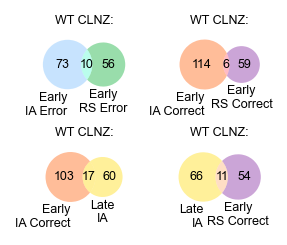

In [49]:
supplement_tag = "supp_"
stage_pairs_WT_CLNZ = [['Early_IA_Error', 'Early_RS_Error'], ['Early_IA_Correct', 'Early_RS_Correct'], ['Early_IA_Correct', 'Late_IA'], ['Late_IA','Early_RS_Correct']]
venn_fig_size = (2.1,1.5)
label_text_align = {0: 'right', 1: 'center'}  #relationship of label pos to what horz alignment to use
## make plot 
hspace = (1.5/venn_fig_size[1])*0.85
wspace = .25
fig, ax_array = plt.subplots(2,2,figsize =venn_fig_size, layout = 'tight', gridspec_kw = {'wspace':wspace,'hspace':hspace}) #(1.5/venn_fig_size[1]) is because 0.75 works for 1.5, so below that, increase spacing, and above that, decrease
for p, ensemble_to_plot in enumerate(stage_pairs_WT_CLNZ):    ## main venn plot info 
    set_colors = {True: tuple(stage_palette_dict[x] for x in ensemble_to_plot),False: ('r', 'g')}[use_custom_venn_colors]
    venn_objs = plot_ensemble_venn(np.array(ax_array.flat[p]), unit_mean_tseries,ensemble_to_plot,['WT CLNZ'], stage_names, set_colors = set_colors, label_text_align= label_text_align)
    
fig_name = supplement_tag + f" WT CLNZ Ensemble overlap - all pairs"
fig_num = 's_2'
save_fig_in_main_fig_dir(fig, fig_name= fig_name, folder_key=fig_num, filetypes_to_save = ['png','svg'])

#### Supp. Fig. 2B- get all ensemble membership overlap including WT CLNZ

Saved 2_s_Supplement- VEH v CLNZ for Het & WT- ensemble proportion overlap_ensemble chisquared_09_Jun_2026.csv to C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output
Output saved to C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output\2_s_Supplement- VEH v CLNZ for Het & WT- ensemble proportion overlap_ensemble chi test_09_Jun_2026.txt
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\supp_fig_2' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\supp_fig_2\09_Jun_2026' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\date_sorted_figures\09_Jun_2026' already exists.


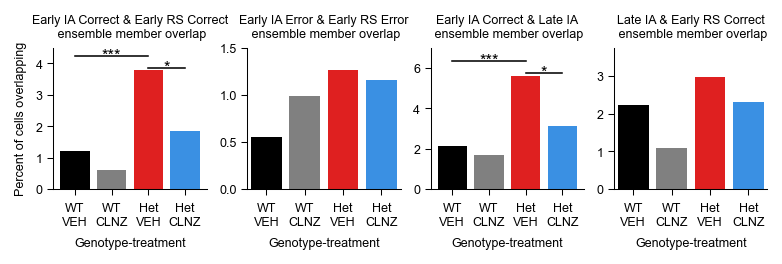

In [50]:
#decide genoplot to amke 
geno_to_plot = ["WT VEH", "WT CLNZ", "Het VEH", "Het CLNZ"]
compare_HET_v_CLNZ_in_WT_VEH= [("WT VEH", "WT CLNZ"), ("Het VEH", "Het CLNZ"), ("WT VEH", "Het VEH")]
sig_ensemble_overlap = [("WT VEH", "Het VEH"), ("Het VEH", "Het CLNZ")]
fig,ax_array = plt.subplots(1,len(all_ensemble_pairs), figsize = (5.1,1.65), layout = 'constrained')
posthoc_df_list = []
ylim_list = [4.5,1.5, 7, 3.75]
## iterate over all wt clnz comparisons
for e, ensemble_to_plot in enumerate(all_ensemble_pairs):
    ax= ax_array.flat[e]
    comparison_mask = (overlap_tab.set_1_name == ensemble_to_plot[0]).values & (overlap_tab.set_2_name == ensemble_to_plot[1]).values
    ensemble_df = overlap_tab.loc[comparison_mask,:]
    plot_df = ensemble_df.loc[ensemble_df.geno_day.isin(geno_to_plot),:]
    plot_params = dict( data =plot_df, x = 'geno_day',y = 'percent_total_overlap',dodge = False,  hue = 'geno_day', hue_order = geno_to_plot, order = geno_to_plot, palette = color_list_WT_CLNZ)
    
    sc= sns.barplot(ax=ax,**plot_params)
    ax_title= f"{' & '.join([x.replace('_', ' ') for x in ensemble_to_plot])}\n ensemble member overlap"
    ylabel = {True:  "Percent of cells overlapping", False: None}
    set_labels(ax, label_dict = dict(title = ax_title, xlabel= "Genotype-treatment", ylabel = ylabel[e ==0], ylim = [0,ylim_list[e]],  legend_false = True))
    
    ##posthoc annot  
    posthoc_df = main_run_posthoc_tests_and_get_hue_loc_df(ax, plot_params, sc, compare_HET_v_CLNZ_in_WT_VEH,test_name = 'none',ax_var_is_hue = True,
                                                               detect_error_bar=False,plot_type= 'barplot') # plot_sig_bars_w_comp_df_tight(plot_ax,  posthoc_df.loc[posthoc_df['pvalue'] < 0.05,:])
    chi_res = [chi2_contingency(plot_df.set_index('geno_day').loc[group,['total_overlap', 'n_total']]) for group in compare_HET_v_CLNZ_in_WT_VEH]
    ## combine into new format
    real_pvalues  = make_premade_comparison_pvalue_df(compare_HET_v_CLNZ_in_WT_VEH, [x.pvalue for x in chi_res])
    posthoc_df= update_posthoc_pvalues(posthoc_df, comparison_pvalues = real_pvalues)    ## make table with precomputed comparison p-value for overwrite  
    posthoc_df.loc[:,'category_compared_within'] = "_x_".join(ensemble_to_plot)
    posthoc_df.stat_result  = [[x.statistic, x.pvalue] for x in chi_res]
    posthoc_df.loc[:,'test_name'] = "chi_squared"
    posthoc_df_list.append(posthoc_df)
    plot_sig_bars_w_comp_df_tight(ax,  posthoc_df.loc[posthoc_df['pvalue'] < 0.05,:],tight_offset = 0.02,offset_constant=0.015)
    ax.set_xticklabels([x.get_text().replace(" ", "\n") for x in ax.get_xticklabels()])
## save it
posthoc_df = pd.concat(posthoc_df_list)
fig_name = f"Supplement- VEH v CLNZ for Het & WT- ensemble proportion overlap"
save_plot_record_as_csv_txt(posthoc_df,folder_pref:="2_s",fig_name,  csv_folder_most_recent, None, csv_suffix="ensemble chisquared",txt_suffix="ensemble chi test")
save_fig_in_main_fig_dir(fig, fig_name= fig_name, folder_key='s_2', filetypes_to_save = ['png','svg'],bbox_inches="tight",pad_inches=0)

#### Figure 5A- Early IA/RS Error Ens overlap 

In [51]:
ensemble_to_plot = ['Early_IA_Error', 'Early_RS_Error']
ens_mask = (overlap_tab.set_1_name == ensemble_to_plot[0]) & (overlap_tab.set_2_name == ensemble_to_plot[1])
overlap_tab.loc[ens_mask, :]

,geno_day,set_1_name,set_2_name,total_overlap,n_total,fraction_total_overlap,percent_total_overlap,n_only_in_set_1,n_only_in_set_2,contingency,statistic,pvalue,dof,expected_frequency
0,WT VEH,Early_IA_Error,Early_RS_Error,6,1080,0.005556,0.555556,80,58,"[[936, 80], [58, 6]]",0.036935,0.847597,1,"[[935.0962962962963, 80.9037037037037], [58.90..."
1,WT CLNZ,Early_IA_Error,Early_RS_Error,10,1019,0.009814,0.981354,73,56,"[[880, 73], [56, 10]]",3.682976,0.054971,1,"[[875.3758586849852, 77.62414131501473], [60.6..."
2,Het VEH,Early_IA_Error,Early_RS_Error,11,874,0.012586,1.258581,76,59,"[[728, 76], [59, 11]]",2.161407,0.141515,1,"[[723.9679633867277, 80.03203661327231], [63.0..."
3,Het CLNZ,Early_IA_Error,Early_RS_Error,10,866,0.011547,1.154734,87,61,"[[708, 87], [61, 10]]",0.369321,0.543375,1,"[[705.9526558891455, 89.04734411085451], [63.0..."
4,Het postCLNZ,Early_IA_Error,Early_RS_Error,11,937,0.011740,1.173959,109,56,"[[761, 109], [56, 11]]",0.530351,0.466459,1,"[[758.5805763073639, 111.41942369263607], [58...."


The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\fig_5' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\fig_5\09_Jun_2026' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\date_sorted_figures\09_Jun_2026' already exists.


c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\code\Function .py Storage\helper_functions.py:167: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig_obj.savefig((save_loc / date_dir / f"{fig_name}{date_tag}.{fig_type}"), **save_args)
c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\code\Function .py Storage\helper_functions.py:173: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig_obj.savefig((date_sorted_loc / f"{folder_key}_{fig_name}{date_tag}.{fig_type}"), **save_args)
c:\Users\13car\anaconda3\envs\local_colab\Lib\site-packages\IPython\core\events.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  func(*args, **kwargs)
c:\Users\13car\anaconda3\envs\local_colab\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: This

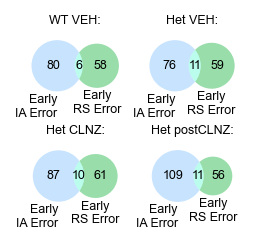

In [52]:
ensemble_to_plot = ['Early_IA_Error', 'Early_RS_Error']
venn_fig_size = (2.,1.5)
label_text_align = {0: 'right', 1: 'center'}  #relationship of label pos to what horz alignment to use

fig, ax_array = plot_save_ensemble_overlap_fig(unit_mean_tseries,
                                   ensemble_to_plot,
                                   geno_order,
                                   stage_names,
                                   venn_fig_size, 
                                   label_text_align = {0: 'right', 1: 'center'}, 
                                   hspace = (1.5/venn_fig_size[1])*0.75,
                                   stage_palette_dict = stage_palette_dict,
                                   fig_num = 5)

In [53]:
def plot_ensemble_percent_overlap(unit_mean_tseries, 
                                  ensemble_to_plot,
                                  stage_names,
                                  geno_order,
                                  color_list,
                                  add_sig_bars=False,
                                  add_legend = False,
                                  sig_ensemble_overlap=[], 
                                  ensemble_pvalue=[],
                                  ylim = None,
                                  test_name = "none"):
    #make plot 
    if ylim != None:
        ax.set_ylim(ylim)

    geno_crosstab = get_geno_stage_overlap_crosstab(unit_mean_tseries, ensemble_to_plot,geno_order,stage_names)##now extract and plot comparison of % overlap ensemble     
    plot_params = dict( data = geno_crosstab, x = 'geno_day',y = 'percent_total_overlap',dodge = False,  hue = 'geno_day', hue_order = geno_order, order = geno_order, palette = color_list)
    sc= sns.barplot(ax=ax,**plot_params)
    ax_title= f"{' & '.join([x.replace('_', ' ') for x in ensemble_to_plot])}\n ensemble membership overlap"
    set_labels(ax, label_dict = dict(title = ax_title, xlabel= "Genotype-treatment", ylabel = "% of cells overlapping", legend_false = True))
    posthoc_df = []
    if add_sig_bars:# get hue loc, overwrite P-value due to external chisquared
        posthoc_df = main_run_posthoc_tests_and_get_hue_loc_df(ax, plot_params, sc, preset_comparison_list,test_name = test_name,detect_error_bar=False,plot_type= 'barplot') # plot_sig_bars_w_comp_df_tight(plot_ax,  posthoc_df.loc[posthoc_df['pvalue'] < 0.05,:])
        posthoc_df= update_posthoc_pvalues(posthoc_df, comparison_pvalues = make_premade_comparison_pvalue_df(sig_ensemble_overlap, ensemble_pvalue))    ## make table with precomputed comparison p-value for overwrite
        plot_sig_bars_w_comp_df_tight(ax,  posthoc_df.loc[posthoc_df['pvalue'] < 0.05,:],tight_offset = 0.03,offset_constant=0.02)
    
    if add_legend:
        hand, labs =ax.get_legend_handles_labels() #pull legend from final PCA object and delete it
        plt.gcf().legend(hand, labs, bbox_to_anchor=(0.55, .975),loc = 'lower center', ncols = 4, frameon = False, title =None, **{
            'labelspacing': 0.05,
            'markerscale': 0.1,
            'borderpad': 0.0,
            'columnspacing': 0.25,
            'handletextpad': 0.15})
    
    ax.set_xticklabels([x.get_text().replace(" ", "\n") for x in ax.get_xticklabels()])
  

    return posthoc_df

In [54]:
member_overlap_figsize = (1.75,1.75)


The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\fig_5' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\fig_5\09_Jun_2026' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\date_sorted_figures\09_Jun_2026' already exists.


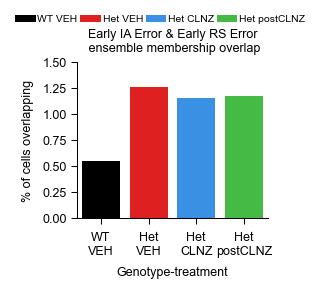

In [55]:
fig, ax = plt.subplots(1,1, figsize =member_overlap_figsize,layout= 'constrained')
#new- preset pvalue due to external chi-squared calculation
add_sig_bars = False
sig_ensemble_overlap = [("WT VEH", "Het VEH"), ("Het VEH", "Het CLNZ")]
ensemble_pvalue = [1,1]
ensemble_to_plot = ['Early_IA_Error', 'Early_RS_Error']

## main fig logic
plot_ens_data = geno_compare_overlap_df[(geno_compare_overlap_df.set_1_name == ensemble_to_plot[0]) & (geno_compare_overlap_df.set_2_name == ensemble_to_plot[1])]
add_sig_bars, sig_ensemble_overlap, ensemble_pvalue = get_sig_ensemble_overlap_diff_by_geno(plot_ens_data[plot_ens_data.pvalue < 0.05])
plot_ensemble_percent_overlap(unit_mean_tseries, ensemble_to_plot,stage_names,geno_order,color_list, add_sig_bars,add_legend = True, sig_ensemble_overlap=sig_ensemble_overlap, ensemble_pvalue= ensemble_pvalue, ylim = [0,1.5])

# #make plot
# plot_ensemble_percent_overlap(unit_mean_tseries, ensemble_to_plot,stage_names,
#                                   geno_order,color_list, add_sig_bars,
#                                   add_legend = True,
#                                   sig_ensemble_overlap=sig_ensemble_overlap, ensemble_pvalue= ensemble_pvalue)
##save fig 
fig_name = f"{'_'.join(ensemble_to_plot)} proportion overlap"
save_fig_in_main_fig_dir(fig, fig_name= fig_name, folder_key=5, filetypes_to_save = ['png','svg'],bbox_inches="tight",pad_inches=0)

#### Figure 6A- Early IA/RS Correct ens overlap 

In [56]:
ensemble_to_plot = ['Early_IA_Correct', 'Early_RS_Correct']
ens_mask = (overlap_tab.set_1_name == ensemble_to_plot[0]) & (overlap_tab.set_2_name == ensemble_to_plot[1])
overlap_tab.loc[ens_mask, :]

,geno_day,set_1_name,set_2_name,total_overlap,n_total,fraction_total_overlap,percent_total_overlap,n_only_in_set_1,n_only_in_set_2,contingency,statistic,pvalue,dof,expected_frequency
0,WT VEH,Early_IA_Correct,Early_RS_Correct,13,1080,0.012037,1.203704,96,57,"[[914, 96], [57, 13]]",4.973187,0.025743,1,"[[908.0648148148148, 101.93518518518519], [62...."
1,WT CLNZ,Early_IA_Correct,Early_RS_Correct,6,1019,0.005888,0.588813,114,59,"[[840, 114], [59, 6]]",0.210841,0.646109,1,"[[841.6545632973504, 112.34543670264965], [57...."
2,Het VEH,Early_IA_Correct,Early_RS_Correct,33,874,0.037757,3.775744,112,25,"[[704, 112], [25, 33]]",69.845844,0.0,1,"[[680.6224256292907, 135.37757437070937], [48...."
3,Het CLNZ,Early_IA_Correct,Early_RS_Correct,16,866,0.018476,1.847575,93,47,"[[710, 93], [47, 16]]",8.91697,0.002825,1,"[[701.9295612009238, 101.07043879907621], [55...."
4,Het postCLNZ,Early_IA_Correct,Early_RS_Correct,22,937,0.023479,2.347919,119,43,"[[753, 119], [43, 22]]",17.759135,0.000025,1,"[[740.7812166488794, 131.2187833511206], [55.2..."


The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\fig_6' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\fig_6\09_Jun_2026' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\date_sorted_figures\09_Jun_2026' already exists.


c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\code\Function .py Storage\helper_functions.py:167: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig_obj.savefig((save_loc / date_dir / f"{fig_name}{date_tag}.{fig_type}"), **save_args)
c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\code\Function .py Storage\helper_functions.py:173: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig_obj.savefig((date_sorted_loc / f"{folder_key}_{fig_name}{date_tag}.{fig_type}"), **save_args)
c:\Users\13car\anaconda3\envs\local_colab\Lib\site-packages\IPython\core\events.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  func(*args, **kwargs)
c:\Users\13car\anaconda3\envs\local_colab\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: This

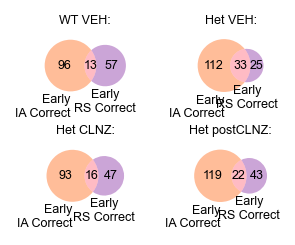

In [57]:
ensemble_to_plot = ['Early_IA_Correct', 'Early_RS_Correct']
venn_fig_size = (2.5,1.5)
label_text_align = {0: 'right', 1: 'center'}  #relationship of label pos to what horz alignment to use
hspace = (1.5/venn_fig_size[1])*0.75

fig, ax_array = plot_save_ensemble_overlap_fig(unit_mean_tseries,
                                   ensemble_to_plot,
                                   geno_order,
                                   stage_names,
                                   venn_fig_size, 
                                   label_text_align = {0: 'right', 1: 'center'}, 
                                   hspace = (1.5/venn_fig_size[1])*0.75,
                                    wspace = 0,
                                    stage_palette_dict = stage_palette_dict,
                                   fig_num = 6)

('xkcd:bright orange', 'xkcd:purple')
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\fig_6' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\fig_6\09_Jun_2026' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\date_sorted_figures\09_Jun_2026' already exists.


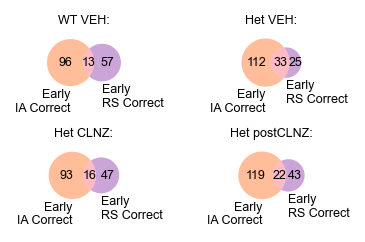

In [58]:
fig, ax_array = plt.subplots(2,2,figsize = venn_fig_size, layout = 'constrained')
ensemble_to_plot = ['Early_IA_Correct', 'Early_RS_Correct']
## main venn plot info 
set_colors = {True: tuple(stage_palette_dict[x] for x in ensemble_to_plot), False: ('r', 'g')}[use_custom_venn_colors]
print(set_colors)
plot_ensemble_venn(ax_array, unit_mean_tseries, ensemble_to_plot, geno_order, stage_names,set_colors = set_colors)
##save overlap fig
fig_name = f"Geno-days- ensemble members- {'_'.join(ensemble_to_plot)} set"
save_fig_in_main_fig_dir(fig, fig_name= fig_name, folder_key=6, filetypes_to_save = ['png','svg'])

The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\fig_6' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\fig_6\09_Jun_2026' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\date_sorted_figures\09_Jun_2026' already exists.


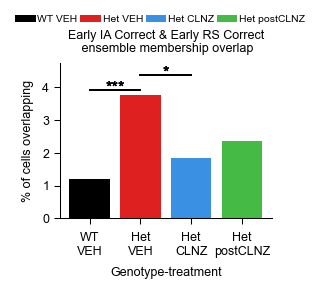

In [59]:
#new- preset pvalue due to external chi-squared calculation
fig, ax = plt.subplots(1,1, figsize =member_overlap_figsize,layout= 'constrained')

add_sig_bars = True
sig_ensemble_overlap = [("WT VEH", "Het VEH"), ("Het VEH", "Het CLNZ"), ("Het VEH", "Het postCLNZ")]
ensemble_pvalue = [0.0011,0.0045]
ensemble_to_plot = ['Early_IA_Correct', 'Early_RS_Correct']
## main fig logic
# # ax.set_ylim([0,4.75])

plot_ens_data = geno_compare_overlap_df[(geno_compare_overlap_df.set_1_name == ensemble_to_plot[0]) & (geno_compare_overlap_df.set_2_name == ensemble_to_plot[1])]
add_sig_bars, sig_ensemble_overlap, ensemble_pvalue = get_sig_ensemble_overlap_diff_by_geno(plot_ens_data[plot_ens_data.pvalue < 0.05])
plot_ensemble_percent_overlap(unit_mean_tseries, ensemble_to_plot,stage_names,geno_order,color_list, add_sig_bars,add_legend = True, sig_ensemble_overlap=sig_ensemble_overlap, ensemble_pvalue= ensemble_pvalue, ylim = [0,4.75])

# plot_ensemble_percent_overlap(unit_mean_tseries, ensemble_to_plot,stage_names,
#                                   geno_order,color_list, add_sig_bars, add_legend = True,
#                                   sig_ensemble_overlap=sig_ensemble_overlap, ensemble_pvalue= ensemble_pvalue, ylim = [0,4.75] )
fig_name = f"{'_'.join(ensemble_to_plot)} proportion overlap"
save_fig_in_main_fig_dir(fig, fig_name= fig_name, folder_key=6, filetypes_to_save = ['png','svg'],bbox_inches="tight",pad_inches=0)

#### Figure 7A- late IA vs. early IA correct for late IA / late IA vs. early RS correct for early RS correct 

In [60]:
ensemble_to_plot = ['Early_IA_Correct', 'Late_IA']
ens_mask = (overlap_tab.set_1_name == ensemble_to_plot[0]) & (overlap_tab.set_2_name == ensemble_to_plot[1])
overlap_tab.loc[ens_mask, :]

,geno_day,set_1_name,set_2_name,total_overlap,n_total,fraction_total_overlap,percent_total_overlap,n_only_in_set_1,n_only_in_set_2,contingency,statistic,pvalue,dof,expected_frequency
0,WT VEH,Early_IA_Correct,Late_IA,23,1080,0.021296,2.129630,86,76,"[[895, 86], [76, 23]]",19.174331,0.000012,1,"[[881.9916666666667, 99.00833333333334], [89.0..."
1,WT CLNZ,Early_IA_Correct,Late_IA,17,1019,0.016683,1.668302,103,60,"[[839, 103], [60, 17]]",7.469386,0.006276,1,"[[831.0677134445535, 110.93228655544651], [67...."
2,Het VEH,Early_IA_Correct,Late_IA,49,874,0.056064,5.606407,96,61,"[[668, 96], [61, 49]]",68.773307,0.0,1,"[[637.2494279176201, 126.75057208237986], [91...."
3,Het CLNZ,Early_IA_Correct,Late_IA,27,866,0.031178,3.117783,82,55,"[[702, 82], [55, 27]]",32.048216,0.0,1,"[[685.3210161662818, 98.67898383371825], [71.6..."
4,Het postCLNZ,Early_IA_Correct,Late_IA,33,937,0.035219,3.521878,108,72,"[[724, 108], [72, 33]]",23.398322,0.000001,1,"[[706.8004268943437, 125.19957310565636], [89...."


The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\fig_7' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\fig_7\09_Jun_2026' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\date_sorted_figures\09_Jun_2026' already exists.


c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\code\Function .py Storage\helper_functions.py:167: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig_obj.savefig((save_loc / date_dir / f"{fig_name}{date_tag}.{fig_type}"), **save_args)
c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\code\Function .py Storage\helper_functions.py:173: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig_obj.savefig((date_sorted_loc / f"{folder_key}_{fig_name}{date_tag}.{fig_type}"), **save_args)
c:\Users\13car\anaconda3\envs\local_colab\Lib\site-packages\IPython\core\events.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  func(*args, **kwargs)
c:\Users\13car\anaconda3\envs\local_colab\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: This

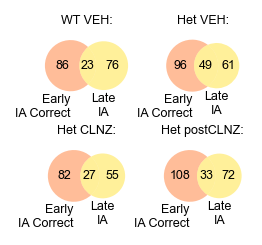

In [61]:
ensemble_to_plot = ['Early_IA_Correct', 'Late_IA']
venn_fig_size = (2.0,1.5)
label_text_align = {0: 'right', 1: 'center'}  #relationship of label pos to what horz alignment to use
hspace = (1.5/venn_fig_size[1])*0.75

fig, ax_array = plot_save_ensemble_overlap_fig(unit_mean_tseries,
                                   ensemble_to_plot,
                                   geno_order,
                                   stage_names,
                                   venn_fig_size, 
                                   label_text_align = {0: 'right', 1: 'center'}, 
                                   hspace = (1.5/venn_fig_size[1])*0.75,
                                    wspace = 0,
                                   stage_palette_dict = stage_palette_dict,
                                   fig_num = 7)

The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\fig_7' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\fig_7\09_Jun_2026' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\date_sorted_figures\09_Jun_2026' already exists.


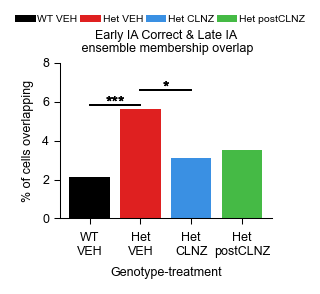

In [62]:
fig, ax = plt.subplots(1,1, figsize =member_overlap_figsize,layout= 'constrained')

#preset pvalue due to external chi-squared calculation
add_sig_bars = True
sig_ensemble_overlap = [("WT VEH", "Het VEH"), ("Het VEH", "Het CLNZ"), ("Het VEH", "Het postCLNZ")]
ensemble_pvalue = [0.0001,0.004,0.032]
ensemble_to_plot = ['Early_IA_Correct', 'Late_IA']
# ## main fig logic

plot_ens_data = geno_compare_overlap_df[(geno_compare_overlap_df.set_1_name == ensemble_to_plot[0]) & (geno_compare_overlap_df.set_2_name == ensemble_to_plot[1])]
add_sig_bars, sig_ensemble_overlap, ensemble_pvalue = get_sig_ensemble_overlap_diff_by_geno(plot_ens_data[plot_ens_data.pvalue < 0.05])
plot_ensemble_percent_overlap(unit_mean_tseries, ensemble_to_plot,stage_names,geno_order,color_list, add_sig_bars,add_legend = True, sig_ensemble_overlap=sig_ensemble_overlap, ensemble_pvalue= ensemble_pvalue, ylim = [0,8])

# plot_ensemble_percent_overlap(unit_mean_tseries, ensemble_to_plot,stage_names, geno_order,color_list, add_sig_bars,
#                               add_legend = True, sig_ensemble_overlap=sig_ensemble_overlap, ensemble_pvalue= ensemble_pvalue, ylim = [0,9])
##save fig 
fig_name = f"{'_'.join(ensemble_to_plot)} proportion overlap"
save_fig_in_main_fig_dir(fig, fig_name= fig_name, folder_key=7, filetypes_to_save = ['png','svg'],bbox_inches="tight",pad_inches=0)

#### Figure 7E- early RS correct vs. late RS ensemble membership overlap

In [63]:
ensemble_to_plot = ['Late_IA','Early_RS_Correct']
ens_mask = (overlap_tab.set_1_name == ensemble_to_plot[0]) & (overlap_tab.set_2_name == ensemble_to_plot[1])
overlap_tab.loc[ens_mask, :]

,geno_day,set_1_name,set_2_name,total_overlap,n_total,fraction_total_overlap,percent_total_overlap,n_only_in_set_1,n_only_in_set_2,contingency,statistic,pvalue,dof,expected_frequency
0,WT VEH,Late_IA,Early_RS_Correct,24,1080,0.022222,2.222222,75,46,"[[935, 75], [46, 24]]",53.541789,0.0,1,"[[917.4166666666666, 92.58333333333333], [63.5..."
1,WT CLNZ,Late_IA,Early_RS_Correct,11,1019,0.010795,1.079490,66,54,"[[888, 66], [54, 11]]",7.346526,0.006719,1,"[[881.9116781157998, 72.0883218842002], [60.08..."
2,Het VEH,Late_IA,Early_RS_Correct,26,874,0.029748,2.974828,84,32,"[[732, 84], [32, 26]]",55.601153,0.0,1,"[[713.2997711670481, 102.70022883295195], [50...."
3,Het CLNZ,Late_IA,Early_RS_Correct,20,866,0.023095,2.309469,62,43,"[[741, 62], [43, 20]]",36.581475,0.0,1,"[[726.9653579676674, 76.03464203233257], [57.0..."
4,Het postCLNZ,Late_IA,Early_RS_Correct,27,937,0.028815,2.881537,78,38,"[[794, 78], [38, 27]]",61.349001,0.0,1,"[[774.2838847385273, 97.71611526147278], [57.7..."


The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\fig_7' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\fig_7\09_Jun_2026' already exists.


c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\code\Function .py Storage\helper_functions.py:167: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig_obj.savefig((save_loc / date_dir / f"{fig_name}{date_tag}.{fig_type}"), **save_args)


The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\date_sorted_figures\09_Jun_2026' already exists.


c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\code\Function .py Storage\helper_functions.py:173: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig_obj.savefig((date_sorted_loc / f"{folder_key}_{fig_name}{date_tag}.{fig_type}"), **save_args)
c:\Users\13car\anaconda3\envs\local_colab\Lib\site-packages\IPython\core\events.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  func(*args, **kwargs)
c:\Users\13car\anaconda3\envs\local_colab\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


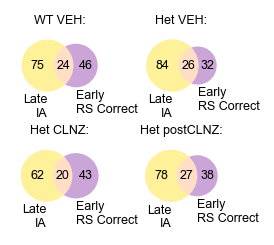

In [64]:
ensemble_to_plot = ['Late_IA','Early_RS_Correct']
venn_fig_size = (2.0,1.5)
label_text_align = {0: 'right', 1: 'left'}  #relationship of label pos to what horz alignment to use
hspace = (1.5/venn_fig_size[1])*0.75

fig, ax_array = plot_save_ensemble_overlap_fig(unit_mean_tseries,
                                   ensemble_to_plot,
                                   geno_order,
                                   stage_names,
                                   venn_fig_size, 
                                   label_text_align = label_text_align, 
                                   hspace = (1.5/venn_fig_size[1])*0.75,
                                    wspace = 0.1,
                                   stage_palette_dict = stage_palette_dict,
                                   fig_num = 7)


The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\fig_7' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\fig_7\09_Jun_2026' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\date_sorted_figures\09_Jun_2026' already exists.


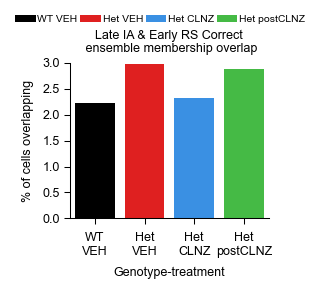

In [65]:
#new- preset pvalue due to external chi-squared calculation
add_sig_bars = True
sig_ensemble_overlap = [("WT VEH", "Het VEH"), ("Het VEH", "Het CLNZ")]
ensemble_pvalue = [0.08,0.15]
ensemble_to_plot = ['Late_IA','Early_RS_Correct']
## main fig logic
fig, ax = plt.subplots(1,1, figsize =member_overlap_figsize,layout= 'constrained')

plot_ens_data = geno_compare_overlap_df[(geno_compare_overlap_df.set_1_name == ensemble_to_plot[0]) & (geno_compare_overlap_df.set_2_name == ensemble_to_plot[1])]
add_sig_bars, sig_ensemble_overlap, ensemble_pvalue = get_sig_ensemble_overlap_diff_by_geno(plot_ens_data[plot_ens_data.pvalue < 0.05])
plot_ensemble_percent_overlap(unit_mean_tseries, ensemble_to_plot,stage_names,geno_order,color_list, add_sig_bars,add_legend = True, sig_ensemble_overlap=sig_ensemble_overlap, ensemble_pvalue= ensemble_pvalue, ylim = [0,3])

# plot_ensemble_percent_overlap(unit_mean_tseries, ensemble_to_plot,stage_names,geno_order,color_list, add_sig_bars,add_legend = True, sig_ensemble_overlap=sig_ensemble_overlap, ensemble_pvalue= ensemble_pvalue)
##save fig 
fig_name = f"{'_'.join(ensemble_to_plot)} proportion overlap"
save_fig_in_main_fig_dir(fig, fig_name= fig_name, folder_key=7, filetypes_to_save = ['png', 'svg'],bbox_inches="tight",pad_inches=0)

## Summary Figures:

#### Tabulate Main fig. membership overlap

In [66]:
genos_compare_ens_overlap = [("WT VEH", "Het VEH"),
                             ("Het VEH", "Het CLNZ"),
                             ("Het VEH", "Het postCLNZ")]
print(genos_compare_ens_overlap)

overlap_pairs = set([z for z in zip(overlap_tab['set_1_name'], overlap_tab['set_2_name'])])
print(overlap_pairs)

[('WT VEH', 'Het VEH'), ('Het VEH', 'Het CLNZ'), ('Het VEH', 'Het postCLNZ')]
{('Late_IA', 'Early_RS_Correct'), ('Early_IA_Correct', 'Late_IA'), ('Early_IA_Correct', 'Early_RS_Correct'), ('Early_IA_Error', 'Early_RS_Error')}


In [67]:
def get_sig_ensemble_overlap_diff_by_geno(sig_ens_data:pd.DataFrame):
    ''' To use for checking if the geno vs geno overlap comparison has a sig difference, and iterating over the elements if so '''
    add_sig_bars = sig_ens_data.shape[0] > 0
    sig_ensemble_overlap, ensemble_pvalue =[], []
    if add_sig_bars:
        for row in sig_ens_data.itertuples():
            sig_geno_diff = (row.geno_day_geno_1, row.geno_day_geno_2)
            sig_geno_pval = row.pvalue
            #append to lists 
            sig_ensemble_overlap.append(sig_geno_diff)
            ensemble_pvalue.append(sig_geno_pval) #new- preset pvalue due to external chi-squared calculation
    return add_sig_bars, sig_ensemble_overlap, ensemble_pvalue

In [68]:
overlap_store = [] #store in list to concat after
for comp in genos_compare_ens_overlap:
    comp_name = "_vs_".join(comp)
    for ens_pair in overlap_pairs:
        print(comp_name, ens_pair)
        #format geno1 comp
        geno_1_df = overlap_tab[overlap_tab.geno_day== comp[0]]
        geno_1_comp = geno_1_df[(geno_1_df.set_1_name == ens_pair[0]) & (geno_1_df.set_2_name == ens_pair[1])].reset_index()

        #geno 2 comp
        geno_2_df = overlap_tab[overlap_tab.geno_day== comp[1]]
        geno_2_comp =geno_2_df[(geno_2_df.set_1_name == ens_pair[0]) & (geno_2_df.set_2_name == ens_pair[1])].reset_index()

        #get overlap
        cols_to_keep = ['geno_day', 'total_overlap', 'n_total']
        geno_compare_overlap_df = geno_1_comp[['set_1_name', 'set_2_name'] + cols_to_keep].join(geno_2_comp[cols_to_keep], lsuffix= "_geno_1", rsuffix = "_geno_2").assign(geno_comparison = comp_name, ensemble_comparison = "_vs_".join(ens_pair))

        # make contingency table: compare [[g1_overlap, g1_nonoverlap], [g2_overlap, g2_nonoverlap]]
        geno_compare_overlap_df['geno_compare_overlap'] = geno_compare_overlap_df.apply(lambda x: np.array([[x.total_overlap_geno_1, x.n_total_geno_1] , [x.total_overlap_geno_2, x.n_total_geno_2]]),axis = 1)
        geno_compare_overlap_df[['statistic', 'pvalue', 'dof', 'expected_frequency']] = geno_compare_overlap_df.apply(lambda x: chi2_contingency(x.geno_compare_overlap), axis=1, result_type='expand').values
        overlap_store.append(geno_compare_overlap_df)
geno_compare_overlap_df = pd.concat(overlap_store)
geno_compare_overlap_df


WT VEH_vs_Het VEH ('Late_IA', 'Early_RS_Correct')
WT VEH_vs_Het VEH ('Early_IA_Correct', 'Late_IA')
WT VEH_vs_Het VEH ('Early_IA_Correct', 'Early_RS_Correct')
WT VEH_vs_Het VEH ('Early_IA_Error', 'Early_RS_Error')
Het VEH_vs_Het CLNZ ('Late_IA', 'Early_RS_Correct')
Het VEH_vs_Het CLNZ ('Early_IA_Correct', 'Late_IA')
Het VEH_vs_Het CLNZ ('Early_IA_Correct', 'Early_RS_Correct')
Het VEH_vs_Het CLNZ ('Early_IA_Error', 'Early_RS_Error')
Het VEH_vs_Het postCLNZ ('Late_IA', 'Early_RS_Correct')
Het VEH_vs_Het postCLNZ ('Early_IA_Correct', 'Late_IA')
Het VEH_vs_Het postCLNZ ('Early_IA_Correct', 'Early_RS_Correct')
Het VEH_vs_Het postCLNZ ('Early_IA_Error', 'Early_RS_Error')


,set_1_name,set_2_name,geno_day_geno_1,total_overlap_geno_1,n_total_geno_1,geno_day_geno_2,total_overlap_geno_2,n_total_geno_2,geno_comparison,ensemble_comparison,geno_compare_overlap,statistic,pvalue,dof,expected_frequency
0,Late_IA,Early_RS_Correct,WT VEH,24,1080,Het VEH,26,874,WT VEH_vs_Het VEH,Late_IA_vs_Early_RS_Correct,"[[24, 1080], [26, 874]]",0.768663,0.380631,1,"[[27.54491017964072, 1076.4550898203593], [22...."
0,Early_IA_Correct,Late_IA,WT VEH,23,1080,Het VEH,49,874,WT VEH_vs_Het VEH,Early_IA_Correct_vs_Late_IA,"[[23, 1080], [49, 874]]",14.308561,0.000155,1,"[[39.19842053307009, 1063.80157946693], [32.80..."
0,Early_IA_Correct,Early_RS_Correct,WT VEH,13,1080,Het VEH,33,874,WT VEH_vs_Het VEH,Early_IA_Correct_vs_Early_RS_Correct,"[[13, 1080], [33, 874]]",12.162182,0.000488,1,"[[25.139, 1067.861], [20.861, 886.139]]"
0,Early_IA_Error,Early_RS_Error,WT VEH,6,1080,Het VEH,11,874,WT VEH_vs_Het VEH,Early_IA_Error_vs_Early_RS_Error,"[[6, 1080], [11, 874]]",1.971123,0.160329,1,"[[9.366818873668189, 1076.633181126332], [7.63..."
0,Late_IA,Early_RS_Correct,Het VEH,26,874,Het CLNZ,20,866,Het VEH_vs_Het CLNZ,Late_IA_vs_Early_RS_Correct,"[[26, 874], [20, 866]]",0.480317,0.488279,1,"[[23.180291153415453, 876.8197088465845], [22...."
0,Early_IA_Correct,Late_IA,Het VEH,49,874,Het CLNZ,27,866,Het VEH_vs_Het CLNZ,Early_IA_Correct_vs_Late_IA,"[[49, 874], [27, 866]]",5.35505,0.020662,1,"[[38.62775330396476, 884.3722466960353], [37.3..."
0,Early_IA_Correct,Early_RS_Correct,Het VEH,33,874,Het CLNZ,16,866,Het VEH_vs_Het CLNZ,Early_IA_Correct_vs_Early_RS_Correct,"[[33, 874], [16, 866]]",4.922646,0.026507,1,"[[24.842370039128003, 882.157629960872], [24.1..."
0,Early_IA_Error,Early_RS_Error,Het VEH,11,874,Het CLNZ,10,866,Het VEH_vs_Het CLNZ,Early_IA_Error_vs_Early_RS_Error,"[[11, 874], [10, 866]]",0.0,1.0,1,"[[10.55366269165247, 874.4463373083476], [10.4..."
0,Late_IA,Early_RS_Correct,Het VEH,26,874,Het postCLNZ,27,937,Het VEH_vs_Het postCLNZ,Late_IA_vs_Early_RS_Correct,"[[26, 874], [27, 937]]",0.0,1.0,1,"[[25.590128755364805, 874.4098712446352], [27...."
0,Early_IA_Correct,Late_IA,Het VEH,49,874,Het postCLNZ,33,937,Het VEH_vs_Het postCLNZ,Early_IA_Correct_vs_Late_IA,"[[49, 874], [33, 937]]",3.701838,0.054353,1,"[[39.98203909138933, 883.0179609086107], [42.0..."


In [69]:
# #given ensemble made, get pvalue and sig overlaps:
# plot_ens_data = geno_compare_overlap_df[(geno_compare_overlap_df.set_1_name == ensemble_to_plot[0]) & (geno_compare_overlap_df.set_2_name == ensemble_to_plot[1])]
# add_sig_bars, sig_ensemble_overlap, ensemble_pvalue = get_sig_ensemble_overlap_diff_by_geno(plot_ens_data[plot_ens_data.pvalue < 0.05])
# add_sig_bars, sig_ensemble_overlap, ensemble_pvalue

# # index chi2 overlap tabulation, then get those with p < 0.05
# curr_venn_contingency = overlap_tab[(overlap_tab.set_1_name == ensemble_to_plot[0]) & (overlap_tab.set_2_name == ensemble_to_plot[1])]
# curr_venn_sig_overlap = curr_venn_contingency[curr_venn_contingency.pvalue < 0.05]
# curr_venn_sig_overlap.columns

add_sig_bars, sig_ensemble_overlap, ensemble_pvalue = (True, [('WT VEH', 'Het VEH'), ('Het VEH', 'Het CLNZ')], [0.00015515760530983294, 0.020662341733314576])
add_sig_bars, sig_ensemble_overlap, ensemble_pvalue = (True, [('WT VEH', 'Het VEH'), ('Het VEH', 'Het CLNZ')], [0.000487683017406148, 0.02650689641195708])
add_sig_bars, sig_ensemble_overlap, ensemble_pvalue = (False, [], [])
Saving Figure 5-7 Ensemble Overlap Quantification_09_Jun_2026
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\fig_7' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\fig_7\09_Jun_2026' already exists.


c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\code\Function .py Storage\helper_functions.py:167: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig_obj.savefig((save_loc / date_dir / f"{fig_name}{date_tag}.{fig_type}"), **save_args)


The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\date_sorted_figures\09_Jun_2026' already exists.


c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\code\Function .py Storage\helper_functions.py:173: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig_obj.savefig((date_sorted_loc / f"{folder_key}_{fig_name}{date_tag}.{fig_type}"), **save_args)
c:\Users\13car\anaconda3\envs\local_colab\Lib\site-packages\IPython\core\events.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  func(*args, **kwargs)
c:\Users\13car\anaconda3\envs\local_colab\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


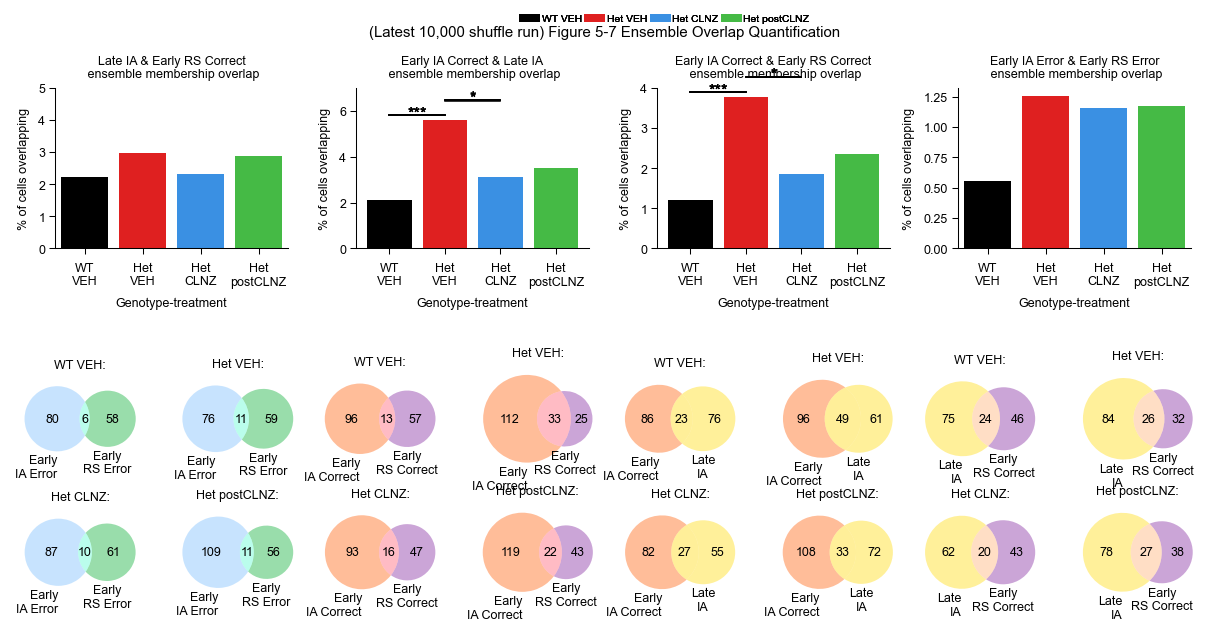

In [70]:
#constant params:
fig = plt.figure(figsize =(8,4),layout= 'tight')
fig.suptitle(f"(Latest 10,000 shuffle run) Figure 5-7 Ensemble Overlap Quantification")
#make subfigs
subfig_array = fig.subfigures(2,1, height_ratios= [0.4,0.6], hspace = 0.2)

#make bar subfig
subfig_n = 0
ax_array_bars = subfig_array[subfig_n].subplots(1,4,)

#plot late IA & Early RS COrrect
ax = ax_array_bars.flat[0]
ensemble_to_plot = ['Late_IA','Early_RS_Correct']
#given ensemble made, get pvalue and sig overlaps:
plot_ens_data = geno_compare_overlap_df[(geno_compare_overlap_df.set_1_name == ensemble_to_plot[0]) & (geno_compare_overlap_df.set_2_name == ensemble_to_plot[1])]
add_sig_bars, sig_ensemble_overlap, ensemble_pvalue = get_sig_ensemble_overlap_diff_by_geno(plot_ens_data[plot_ens_data.pvalue < 0.05])
plot_ensemble_percent_overlap(unit_mean_tseries, ensemble_to_plot,stage_names,geno_order,color_list, add_sig_bars,add_legend = True, sig_ensemble_overlap=sig_ensemble_overlap, ensemble_pvalue= ensemble_pvalue, ylim = [0,5])

#plot early IA Correct vs Late IA
ax = ax_array_bars.flat[1]
ensemble_to_plot = ['Early_IA_Correct', 'Late_IA']
#given ensemble made, get pvalue and sig overlaps:
plot_ens_data = geno_compare_overlap_df[(geno_compare_overlap_df.set_1_name == ensemble_to_plot[0]) & (geno_compare_overlap_df.set_2_name == ensemble_to_plot[1])]
add_sig_bars, sig_ensemble_overlap, ensemble_pvalue = get_sig_ensemble_overlap_diff_by_geno(plot_ens_data[plot_ens_data.pvalue < 0.05])
print(f"add_sig_bars, sig_ensemble_overlap, ensemble_pvalue = {add_sig_bars, sig_ensemble_overlap, ensemble_pvalue}")
plot_ensemble_percent_overlap(unit_mean_tseries, ensemble_to_plot,stage_names, geno_order,color_list, add_sig_bars,add_legend = True, sig_ensemble_overlap=sig_ensemble_overlap, ensemble_pvalue= ensemble_pvalue, ylim = [0,7])

## plot IA vs RS Correct:
ax = ax_array_bars.flat[2]
ensemble_to_plot = ['Early_IA_Correct', 'Early_RS_Correct']
plot_ens_data = geno_compare_overlap_df[(geno_compare_overlap_df.set_1_name == ensemble_to_plot[0]) & (geno_compare_overlap_df.set_2_name == ensemble_to_plot[1])]
add_sig_bars, sig_ensemble_overlap, ensemble_pvalue = get_sig_ensemble_overlap_diff_by_geno(plot_ens_data[plot_ens_data.pvalue < 0.05])
print(f"add_sig_bars, sig_ensemble_overlap, ensemble_pvalue = {add_sig_bars, sig_ensemble_overlap, ensemble_pvalue}")
plot_ensemble_percent_overlap(unit_mean_tseries, ensemble_to_plot,stage_names,geno_order,color_list, add_sig_bars, add_legend = True, sig_ensemble_overlap=sig_ensemble_overlap, ensemble_pvalue= ensemble_pvalue, ylim = [0,4])

## plot IA vs RS Error:
ax = ax_array_bars.flat[3]
ensemble_to_plot = ['Early_IA_Error', 'Early_RS_Error']
plot_ens_data = geno_compare_overlap_df[(geno_compare_overlap_df.set_1_name == ensemble_to_plot[0]) & (geno_compare_overlap_df.set_2_name == ensemble_to_plot[1])]
add_sig_bars, sig_ensemble_overlap, ensemble_pvalue = get_sig_ensemble_overlap_diff_by_geno(plot_ens_data[plot_ens_data.pvalue < 0.05])
print(f"add_sig_bars, sig_ensemble_overlap, ensemble_pvalue = {add_sig_bars, sig_ensemble_overlap, ensemble_pvalue}")
plot_ensemble_percent_overlap(unit_mean_tseries, ensemble_to_plot,stage_names,geno_order,color_list, add_sig_bars, add_legend = True, sig_ensemble_overlap=sig_ensemble_overlap, ensemble_pvalue= ensemble_pvalue)

#### #make VENN  subfig
subfig_n = 1
subfigs_venn = subfig_array[subfig_n].subfigures(1,4, )
hspace = 0.25
wspace = .25
#all comps:
all_ens_venn = [['Early_IA_Error', 'Early_RS_Error'], ['Early_IA_Correct', 'Early_RS_Correct'], ['Early_IA_Correct', 'Late_IA'],['Late_IA','Early_RS_Correct']]
label_text_align = {0: 'right', 1: 'center'}  #relationship of label pos to what horz alignment to use
## make plot 
for e, ensemble_to_plot in enumerate(all_ens_venn):
    ax_array = subfigs_venn[e].subplots(2,2, gridspec_kw = {'wspace':wspace,'hspace':hspace}) #(1.5/venn_fig_size[1]) is because 0.75 works for 1.5, so below that, increase spacing, and above that, decrease
    venn_objs = plot_ensemble_venn(ax_array, 
                                unit_mean_tseries,
                                    ensemble_to_plot,
                                    geno_order,
                                        stage_names,
                                        set_colors = tuple(stage_palette_dict[x] for x in ensemble_to_plot), 
                                        label_text_align = label_text_align)

fig_name = f"Figure 5-7 Ensemble Overlap Quantification_{date_tag}"
print(f"Saving {fig_name}")
save_fig_in_main_fig_dir(fig, fig_name= fig_name, folder_key=7, filetypes_to_save = ['png'],bbox_inches="tight",pad_inches=0)